# 02 - Data Preprocessing: Dataset Splitting

**Project:** SpaHisto-Net  
**Dataset:** STimage-1K4M Breast Cancer Subset

## Splitting Strategy (70:15:15)

- **Training set**:
  - All 24 annotated samples (strong supervision)
  - All 6 normal (non-cancer) samples (strong supervision)
  - ~70% of the remaining non-annotated samples
- **Validation set**: ~15% of the non-annotated samples
- **Test set**: ~15% of the non-annotated samples

All annotated and normal samples are kept **exclusively in the training set** to avoid data leakage and ensure the model learns from high-quality labels.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Set up Paths

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import os


# ====================== PROJECT PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "STimage-1k4M"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

# Metadata file
META_PATH = PROJECT_ROOT / "data" / "raw" / "STimage-1k4M" / "meta_all_gene.csv"
# ===========================================================

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)

Project root: /content/drive/My Drive/MSC Project/SpaHisto-Net
Raw data folder: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/raw/STimage-1k4M


In [ ]:
def extract_patient_id(slide):
    """
    Extract distinct study/patient group from slide name.
    Each unique study (Anderson, Wu, He, Stahl, 10x, GSE, etc.) becomes its own group.
    """
    slide = str(slide)

    if slide.startswith("GSE"):
        # e.g. GSE203612_GSM6177599 → GSE203612
        return slide.split("_")[0]

    elif slide.startswith("Human_Breast_"):
        # e.g. Human_Breast_Anderson_xxx → Human_Breast_Anderson
        #      Human_Breast_Wu_xxx     → Human_Breast_Wu
        parts = slide.split("_")
        if len(parts) >= 3:
            return f"{parts[0]}_{parts[1]}_{parts[2]}"
        else:
            return slide

    else:
        # Fallback for unexpected formats
        return slide.split("_")[0]

In [ ]:
# Load metadata
meta = pd.read_csv(META_PATH)
meta_breast = meta[meta['tissue'] == 'breast'].copy()

# Apply the function
meta_breast['patient_id'] = meta_breast['slide'].apply(extract_patient_id)

print("=" * 70)
print("TESTING: extract_patient_id FUNCTION")
print("=" * 70)

print(f"\nTotal breast samples: {len(meta_breast)}")
print(f"Unique patient/study groups: {meta_breast['patient_id'].nunique()}")

print("\n" + "-" * 70)
print("Distribution of groups:")
print("-" * 70)
print(meta_breast['patient_id'].value_counts())

print("\n" + "-" * 70)
print("Examples of original slide → extracted patient_id:")
print("-" * 70)
sample_examples = meta_breast[['slide', 'patient_id']].drop_duplicates().head(15)
for _, row in sample_examples.iterrows():
    print(f"{row['slide'][:45]:<45} → {row['patient_id']}")

print("\n" + "=" * 70)

TESTING: extract_patient_id FUNCTION

Total breast samples: 205
Unique patient/study groups: 11

----------------------------------------------------------------------
Distribution of groups:
----------------------------------------------------------------------
patient_id
Human_Breast_He           68
GSE210616                 43
Human_Breast_Andersson    36
GSE242311                 16
GSE213688                 14
Human_Breast_10X           6
GSE212482                  6
Human_Breast_Wu            5
Human_Breast_Stahl         4
GSE214571                  4
GSE203612                  3
Name: count, dtype: int64

----------------------------------------------------------------------
Examples of original slide → extracted patient_id:
----------------------------------------------------------------------
Human_Breast_Andersson_10142021_ST_A1         → Human_Breast_Andersson
Human_Breast_Andersson_10142021_ST_A2         → Human_Breast_Andersson
Human_Breast_Andersson_10142021_ST_A3        

In [ ]:
# Load metadata
meta = pd.read_csv(META_PATH)
meta_breast = meta[meta['tissue'] == 'breast'].copy()
meta_breast['patient_id'] = meta_breast['slide'].apply(extract_patient_id)

print("=" * 75)
print("TECHNOLOGY DISTRIBUTION PER PATIENT/STUDY GROUP")
print("=" * 75)

# Cross-tabulation of patient_id vs tech
tech_dist = pd.crosstab(meta_breast['patient_id'], meta_breast['tech'], margins=True)
print(tech_dist)

print("\n" + "=" * 75)
print("OVERALL TECHNOLOGY DISTRIBUTION (All 205 breast samples)")
print("=" * 75)
print(meta_breast['tech'].value_counts())
print("\nProportions:")
print(meta_breast['tech'].value_counts(normalize=True).round(3))

print("\n" + "=" * 75)
print("TECHNOLOGY DISTRIBUTION IN ANNOTATED SAMPLES ONLY")
print("=" * 75)

# Use the 'annotated_samples' list derived from the annotation filename logic
annotated_meta = meta_breast[meta_breast['slide'].isin(annotated_samples)]
print(annotated_meta['tech'].value_counts())

print("\n" + "=" * 75)
print("TECHNOLOGY DISTRIBUTION IN NORMAL SAMPLES ONLY")
print("=" * 75)

# Use the 'normal_samples_in_data' list
normal_meta = meta_breast[meta_breast['slide'].isin(normal_samples_in_data)]
print(normal_meta['tech'].value_counts())

TECHNOLOGY DISTRIBUTION PER PATIENT/STUDY GROUP
tech                     ST  Visium  All
patient_id                              
GSE203612                 0       3    3
GSE210616                 0      43   43
GSE212482                 0       6    6
GSE213688                 0      14   14
GSE214571                 0       4    4
GSE242311                 0      16   16
Human_Breast_10X          0       6    6
Human_Breast_Andersson   36       0   36
Human_Breast_He          68       0   68
Human_Breast_Stahl        4       0    4
Human_Breast_Wu           0       5    5
All                     108      97  205

OVERALL TECHNOLOGY DISTRIBUTION (All 205 breast samples)
tech
ST        108
Visium     97
Name: count, dtype: int64

Proportions:
tech
ST        0.527
Visium    0.473
Name: proportion, dtype: float64

TECHNOLOGY DISTRIBUTION IN ANNOTATED SAMPLES ONLY
tech
Visium    16
ST         8
Name: count, dtype: int64

TECHNOLOGY DISTRIBUTION IN NORMAL SAMPLES ONLY
tech
Visium    6
Name

In [ ]:
import pandas as pd

meta = pd.read_csv(META_PATH)
meta_breast = meta[meta['tissue'] == 'breast'].copy()
meta_breast['patient_id'] = meta_breast['slide'].apply(extract_patient_id)

# Identify annotated samples from folder structure
annotated_samples_from_dirs = []
for sample_folder in RAW_DATA_DIR.iterdir():
    if sample_folder.is_dir():
        annotation_filename = f"{sample_folder.name}_anno.csv"
        if (sample_folder / annotation_filename).exists():
            annotated_samples_from_dirs.append(sample_folder.name)

# Ensure annotated_samples only includes those present in meta_breast
all_meta_slides = set(meta_breast['slide'].unique())
annotated_samples = list(set(annotated_samples_from_dirs).intersection(all_meta_slides))

# Identify normal samples from metadata that also exist in raw data directories
normal_samples_from_meta = meta_breast[meta_breast['involve_cancer'] == False]['slide'].tolist()
normal_samples_in_data = [s for s in normal_samples_from_meta if (RAW_DATA_DIR / s).exists()]
# Ensure normal_samples_in_data only includes those present in meta_breast (redundant but good for clarity)
normal_samples_in_data = list(set(normal_samples_in_data).intersection(all_meta_slides))

print(f"Annotated samples (in metadata): {len(annotated_samples)}")
print(f"Normal samples (in metadata and raw data): {len(normal_samples_in_data)}")

# Calculate overlap and total unique excluded samples for clarity
overlap_samples_set = set(annotated_samples).intersection(set(normal_samples_in_data))
print(f"Number of samples that are both annotated and normal: {len(overlap_samples_set)}")

total_unique_excluded = len(set(annotated_samples) | set(normal_samples_in_data))
print(f"Total unique samples to be excluded (annotated OR normal): {total_unique_excluded}")

# Total breast samples from meta_breast for context
all_meta_slides_count = len(all_meta_slides)
print(f"Total breast samples in meta_breast: {all_meta_slides_count}")

# Samples to be split calculation
calculated_samples_to_split = all_meta_slides_count - total_unique_excluded
print(f"Calculated samples to split (Total - unique excluded): {calculated_samples_to_split}")

Annotated samples (in metadata): 24
Normal samples (in metadata and raw data): 6
Number of samples that are both annotated and normal: 2
Total unique samples to be excluded (annotated OR normal): 28
Total breast samples in meta_breast: 205
Calculated samples to split (Total - unique excluded): 177


In [ ]:
print(f"Overlapping samples (annotated AND normal): {list(overlap_samples_set)}")

Overlapping samples (annotated AND normal): ['Human_Breast_10X_06232020_Visium_Block_A_Section_1', 'Human_Breast_10X_06092021_Visium']


In [ ]:
import pandas as pd
import numpy as np

# Load metadata and prepare meta_breast
# Assuming 'META_PATH' and 'extract_patient_id' are defined from previous cells (FzkexwsVS0dJ and JnTAY875yILj).
meta = pd.read_csv(META_PATH)
meta_breast = meta[meta['tissue'] == 'breast'].copy()
meta_breast['patient_id'] = meta_breast['slide'].apply(extract_patient_id)

# Identify annotated samples from folder structure
# Assuming 'RAW_DATA_DIR' is defined from previous cell FzkexwsVS0dJ.
annotated_samples_from_dirs = []
for sample_folder in RAW_DATA_DIR.iterdir():
    if sample_folder.is_dir():
        annotation_filename = f"{sample_folder.name}_anno.csv"
        if (sample_folder / annotation_filename).exists():
            annotated_samples_from_dirs.append(sample_folder.name)

# Ensure annotated_samples only includes those present in meta_breast
all_meta_slides = set(meta_breast['slide'].unique())
annotated_samples = list(set(annotated_samples_from_dirs).intersection(all_meta_slides))

# Identify normal samples from metadata that also exist in raw data directories
normal_samples_from_meta = meta_breast[meta_breast['involve_cancer'] == False]['slide'].tolist()
normal_samples_in_data = [s for s in normal_samples_from_meta if (RAW_DATA_DIR / s).exists()]
normal_samples_in_data = list(set(normal_samples_in_data).intersection(all_meta_slides))

# Re-evaluate all_samples_in_data from the raw data directory
all_samples_in_data = [f.name for f in RAW_DATA_DIR.iterdir() if f.is_dir()]

samples_to_split = [
    s for s in all_samples_in_data
    if s not in annotated_samples and s not in normal_samples_in_data
]

print(f"Samples to split: {len(samples_to_split)}")

# Prepare dataframe for grouped splitting
split_df = meta_breast[meta_breast['slide'].isin(samples_to_split)].copy()
split_df = split_df.set_index('slide')

# Get unique groups and their sizes
group_sizes = split_df.groupby('patient_id').size().sort_values(ascending=False)
print("\nGroup sizes (sorted):")
print(group_sizes)

# === Controlled Grouped Split (70:15:15) ===
# Total samples to split: 177
# Target Train: ~124 (70%)
# Target Val: ~27 (15%)
# Target Test: ~26 (15%)

# Sort groups by size (largest first)
sorted_groups = group_sizes.index.tolist()

# Manually assign groups to achieve a better balance for 70:15:15 split
# We'll build val and test first, then assign remaining to train

val_groups = ['Human_Breast_Andersson'] # 28 samples (close to 15% target of 27)
test_groups = ['GSE242311', 'GSE212482', 'GSE214571'] # 16 + 6 + 4 = 26 samples (close to 15% target of 26)

assigned_groups = set(val_groups + test_groups)
train_groups = [g for g in sorted_groups if g not in assigned_groups]

print(f"\nAssigned groups:")
print(f"  Train groups: {train_groups}")
print(f"  Val groups  : {val_groups}")
print(f"  Test groups : {test_groups}")

# Get actual sample lists
train_non_annot = split_df[split_df['patient_id'].isin(train_groups)].index.tolist()
val_slides      = split_df[split_df['patient_id'].isin(val_groups)].index.tolist()
test_slides     = split_df[split_df['patient_id'].isin(test_groups)].index.tolist()

print(f"\nFinal non-annotated split:")
print(f"  Train: {len(train_non_annot)}")
print(f"  Val  : {len(val_slides)}")
print(f"  Test : {len(test_slides)}")

print(f"\nTrain percentage: {len(train_non_annot) / len(samples_to_split) * 100:.1f}%")
print(f"Val percentage:   {len(val_slides) / len(samples_to_split) * 100:.1f}%")
print(f"Test percentage:  {len(test_slides) / len(samples_to_split) * 100:.1f}%")

Samples to split: 177

Group sizes (sorted):
patient_id
Human_Breast_He           68
GSE210616                 43
Human_Breast_Andersson    28
GSE242311                 16
GSE212482                  6
Human_Breast_Wu            5
GSE214571                  4
Human_Breast_Stahl         4
GSE203612                  3
dtype: int64

Assigned groups:
  Train groups: ['Human_Breast_He', 'GSE210616', 'Human_Breast_Wu', 'Human_Breast_Stahl', 'GSE203612']
  Val groups  : ['Human_Breast_Andersson']
  Test groups : ['GSE242311', 'GSE212482', 'GSE214571']

Final non-annotated split:
  Train: 123
  Val  : 28
  Test : 26

Train percentage: 69.5%
Val percentage:   15.8%
Test percentage:  14.7%


In [ ]:
# Combine all components of the training set
final_train_slides = list(set(annotated_samples) | set(normal_samples_in_data) | set(train_non_annot))

print(f"\nTotal slides in meta_breast: {len(all_meta_slides)}")
print(f"Final Train Set Size: {len(final_train_slides)}")
print(f"Validation Set Size:  {len(val_slides)}")
print(f"Test Set Size:        {len(test_slides)}")

# Verify no overlaps between train, val, test
if set(final_train_slides).intersection(set(val_slides)):
    print("WARNING: Overlap between final_train_slides and val_slides!")
if set(final_train_slides).intersection(set(test_slides)):
    print("WARNING: Overlap between final_train_slides and test_slides!")
if set(val_slides).intersection(set(test_slides)):
    print("WARNING: Overlap between val_slides and test_slides!")

# Verify sum of splits equals total samples in meta_breast (excluding any missing from data dir)
combined_split_count = len(final_train_slides) + len(val_slides) + len(test_slides)
print(f"Combined split count: {combined_split_count}")

# If everything aligns, save the splits
# It's good practice to save these as simple text files or CSVs, one slide ID per line

pd.DataFrame({'slide': final_train_slides}).to_csv(SPLITS_DIR / "train_slides.csv", index=False)
pd.DataFrame({'slide': val_slides}).to_csv(SPLITS_DIR / "val_slides.csv", index=False)
pd.DataFrame({'slide': test_slides}).to_csv(SPLITS_DIR / "test_slides.csv", index=False)

print(f"\nSplits saved to: {SPLITS_DIR}")
print(f"  - train_slides.csv ({len(final_train_slides)} samples)")
print(f"  - val_slides.csv ({len(val_slides)} samples)")
print(f"  - test_slides.csv ({len(test_slides)} samples)")


Total slides in meta_breast: 205
Final Train Set Size: 151
Validation Set Size:  28
Test Set Size:        26
Combined split count: 205

Splits saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/splits
  - train_slides.csv (151 samples)
  - val_slides.csv (28 samples)
  - test_slides.csv (26 samples)


In [ ]:
# Define paths for the split folders
TRAIN_DATA_DIR = SPLITS_DIR / "train"
VAL_DATA_DIR = SPLITS_DIR / "val"
TEST_DATA_DIR = SPLITS_DIR / "test"

# Create the split directories if they don't exist
TRAIN_DATA_DIR.mkdir(parents=True, exist_ok=True)
VAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
TEST_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Created split directories:")
print(f"  - {TRAIN_DATA_DIR}")
print(f"  - {VAL_DATA_DIR}")
print(f"  - {TEST_DATA_DIR}")

# Load the slide IDs from the saved CSV files
train_slides_df = pd.read_csv(SPLITS_DIR / "train_slides.csv")
val_slides_df = pd.read_csv(SPLITS_DIR / "val_slides.csv")
test_slides_df = pd.read_csv(SPLITS_DIR / "test_slides.csv")

train_slides_list = train_slides_df['slide'].tolist()
val_slides_list = val_slides_df['slide'].tolist()
test_slides_list = test_slides_df['slide'].tolist()

Created split directories:
  - /content/drive/My Drive/MSC Project/SpaHisto-Net/data/splits/train
  - /content/drive/My Drive/MSC Project/SpaHisto-Net/data/splits/val
  - /content/drive/My Drive/MSC Project/SpaHisto-Net/data/splits/test


## 2.2 Patch Extraction from H&E Images

We extract **fixed-size patches of 224 × 224 pixels** centered on the `(xaxis, yaxis)` coordinates from the `coord.csv` file.

To enable efficient storage, fast random access, and easy integration with PyTorch during model training, we save the extracted patches in **HDF5 (.h5)** format instead of individual image files.

For each sample, we create one `.h5` file containing:
- `patches`: NumPy array of shape `(num_spots, 224, 224, 3)` stored as `uint8`
- `coords`: Original `(x, y)` coordinates of shape `(num_spots, 2)`



In [ ]:
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_PATCH_DIR = PROJECT_ROOT / "data" / "processed" / "patches"

In [ ]:
!pip install torchstain

In [ ]:
from PIL import Image

# Increase the limit for decompression bomb protection
# Default is 178,956,970 pixels for Pillow 9.1.0
# We'll set it to a larger value, for example, 2 Gigapixels (2,000,000,000 pixels)
Image.MAX_IMAGE_PIXELS = 2000000000
print(f"Pillow's MAX_IMAGE_PIXELS set to {Image.MAX_IMAGE_PIXELS}")

Pillow's MAX_IMAGE_PIXELS set to 2000000000


In [ ]:
import h5py
import numpy as np
from PIL import Image
from pathlib import Path
from torchvision import transforms
import pandas as pd
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt

def extract_high_quality_patches(sample_dir, output_h5_path, patch_size=224, min_tissue_percent=0.35, debug_visualize=False, max_pixel_count=np.inf):
    """
    Extract 224x224 patches with tissue-aware filtering.
    Only saves patches that contain sufficient tissue.
    """
    sample_dir = Path(sample_dir)
    sample_name = sample_dir.name
    output_h5_path = Path(output_h5_path)

    # Load image
    img_path = sample_dir / f"{sample_name}.png"
    if not img_path.exists():
        # Fallback to check for any .png if the direct match doesn't exist
        png_files = list(sample_dir.glob("*.png"))
        if png_files:
            img_path = png_files[0]
        else:
            raise FileNotFoundError(f"No .png image found in {sample_dir}")

    img = Image.open(img_path).convert("RGB")

    # Debug: Print image dimensions and check for validity
    print(f"  Debug: Image dimensions for {sample_name}: {img.width}x{img.height}")

    # Check if the image exceeds the maximum pixel count
    if img.width * img.height > max_pixel_count:
        print(f"  Skipping '{sample_name}': Image pixel count ({img.width * img.height}) exceeds max_pixel_count ({max_pixel_count}).")
        return -1 # Return -1 to indicate skipped due to size

    if img.width <= 0 or img.height <= 0:
        raise ValueError(f"Image has invalid dimensions (width={img.width}, height={img.height}) after loading.")

    img_np = np.array(img)

    # Ensure img_np is always a 3-channel array before further processing
    if img_np.ndim == 2:
        # Grayscale (H, W) -> Convert to RGB (H, W, 3)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif img_np.ndim == 3 and img_np.shape[2] == 1:
        # Grayscale (H, W, 1) -> Convert to RGB (H, W, 3)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif img_np.ndim == 4:
        # RGBA (H, W, 4) -> Convert to RGB (H, W, 3)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGBA2RGB)
    elif not (img_np.ndim == 3 and img_np.shape[2] == 3):
        # If after all conversions, it's still not (H, W, 3), raise error
        raise ValueError(f"Unexpected image array shape after channel standardization: {img_np.shape} for {sample_name}. Expected a 3-channel array.")

    # === Simple tissue detection (Otsu + Morphology) ===
    # Now using the original img_np (ensured to be 3-channel RGB) for grayscale conversion
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Clean up the mask
    kernel = np.ones((5, 5), np.uint8)
    tissue_mask = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    tissue_mask = cv2.morphologyEx(tissue_mask, cv2.MORPH_OPEN, kernel)

    # === DEBUG VISUALIZATION ===
    if debug_visualize:
        print(f"  DEBUG VISUALIZATION for {sample_name}:")
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.imshow(gray, cmap='gray')
        plt.title('Grayscale Image')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(binary, cmap='gray')
        plt.title("Otsu's Threshold (Binary Inverse)")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(tissue_mask, cmap='gray')
        plt.title('Final Tissue Mask (after Morphology)')
        plt.axis('off')
        plt.show()
    # === END DEBUG VISUALIZATION ===

    # Load coordinates
    coord_path = sample_dir / f"{sample_name}_coord.csv"
    if not coord_path.exists():
        # Fallback to check for any *_coord.csv if the direct match doesn't exist
        coord_files = list(sample_dir.glob("*_coord.csv"))
        if coord_files:
            coord_path = coord_files[0]
        else:
            raise FileNotFoundError(f"No *_coord.csv file found in {sample_dir}")

    coords_df = pd.read_csv(coord_path)

    # Explicitly check for 'xaxis' and 'yaxis' as per user's context
    if {'xaxis', 'yaxis'}.issubset(coords_df.columns):
        x_col, y_col = 'xaxis', 'yaxis'
    elif {'x', 'y'}.issubset(coords_df.columns):
        x_col, y_col = 'x', 'y'
    else:
        raise ValueError(f"Coordinate columns 'xaxis' and 'yaxis' or 'x' and 'y' not found in {coord_path}. Available columns: {coords_df.columns.tolist()})")

    valid_patches = []
    valid_coords = []

    for idx, row in coords_df.iterrows():
        x, y = int(row[x_col]), int(row[y_col])

        # Calculate crop box safely
        left = max(0, x - patch_size // 2)
        top = max(0, y - patch_size // 2)
        right = min(img.width, left + patch_size)
        bottom = min(img.height, top + patch_size)

        # Ensure we always have a valid crop box
        if right <= left or bottom <= top:
            continue

        # Crop from the original (standardized) image_np
        patch = Image.fromarray(img_np).crop((left, top, right, bottom))

        # Pad if smaller than 224 x 224
        if patch.size != (patch_size, patch_size):
            new_patch = Image.new("RGB", (patch_size, patch_size), (255, 255, 255))
            new_patch.paste(patch, (0, 0))
            patch = new_patch

        patch_np = np.array(patch)

        # === Calculate tissue percentage in this patch ===
        # Ensure the patch_mask coordinates are within the bounds of tissue_mask
        mask_top = max(0, top)
        mask_bottom = min(img.height, top + patch_size)
        mask_left = max(0, left)
        mask_right = min(img.width, left + patch_size)

        patch_mask_region = tissue_mask[mask_top:mask_bottom, mask_left:mask_right]

        if patch_mask_region.size == 0:
            tissue_percent = 0
        else:
            tissue_percent = np.sum(patch_mask_region > 0) / patch_mask_region.size

        # Only keep patches with sufficient tissue
        if tissue_percent >= min_tissue_percent:
            valid_patches.append(patch_np) # Append the raw patch
            valid_coords.append([x, y])

    if len(valid_patches) == 0:
        print(f"  Warning: No patches passed tissue filter for {sample_name} with min_tissue_percent={min_tissue_percent}")
        return 0

    valid_patches = np.array(valid_patches, dtype=np.uint8)
    valid_coords = np.array(valid_coords, dtype=np.int32)

    # Save to HDF5
    output_h5_path.parent.mkdir(parents=True, exist_ok=True)

    with h5py.File(output_h5_path, 'w') as f:
        f.create_dataset('patches', data=valid_patches, compression='gzip')
        f.create_dataset('coords', data=valid_coords, compression='gzip')
        f.attrs['num_spots'] = len(valid_patches)
        f.attrs['patch_size'] = patch_size
        f.attrs['sample_name'] = sample_name
        f.attrs['min_tissue_percent'] = min_tissue_percent

    return len(valid_patches)

In [ ]:
import pickle

MIN_TISSUE = 0.35   # Adjust between 0.30 – 0.45 depending on your data
MAX_PIXEL_COUNT = 500_000_000 # Max 500 million pixels. Images larger than this will be skipped.

# Define output directories for HDF5 patches
H5_PATCHES_TRAIN_DIR = PROCESSED_PATCH_DIR / "train"
H5_PATCHES_VAL_DIR = PROCESSED_PATCH_DIR / "val"
H5_PATCHES_TEST_DIR = PROCESSED_PATCH_DIR / "test"


# Ensure all HDF5 output directories exist and are clean
import shutil

# List of all H5 output directories
all_h5_output_dirs = [H5_PATCHES_TRAIN_DIR, H5_PATCHES_VAL_DIR, H5_PATCHES_TEST_DIR]

# Clear and recreate all of them
for h5_output_dir in all_h5_output_dirs:
    # if h5_output_dir.exists():
    #     print(f"Clearing existing HDF5 directory: {h5_output_dir}")
    #     shutil.rmtree(h5_output_dir)
    h5_output_dir.mkdir(parents=True, exist_ok=True)
    # print(f"Created HDF5 directory: {h5_output_dir}")

# ====================== PROCESSING ======================
processing_splits = [
    (RAW_DATA_DIR / "train", H5_PATCHES_TRAIN_DIR, "train"),
    (RAW_DATA_DIR / "val",   H5_PATCHES_VAL_DIR,   "val"),
    (RAW_DATA_DIR / "test",  H5_PATCHES_TEST_DIR,  "test"),
]
# It defines the raw input directories and the target HDF5 output directories.

print("\nStarting high-quality patch extraction...")

total_patches_extracted = 0
error_slides = []
skipped_slides_large_image = [] # New list for skipped slides

for raw_split_dir, output_h5_dir, split_name in processing_splits:
    print(f"\n{'='*60}")
    print(f"Processing {split_name} Split (min tissue = {MIN_TISSUE})")
    print('='*60)

    if not raw_split_dir.exists():
        print(f"WARNING: Input raw split directory not found: {raw_split_dir}. Skipping.")
        continue

    # Get all individual slide folders within this specific split directory (e.g., RAW_DATA_DIR/train)
    slide_folders_in_split = sorted([f for f in raw_split_dir.iterdir() if f.is_dir()])

    for sample_folder in tqdm(slide_folders_in_split, desc=f"Extracting patches for {split_name}"):
        slide_name = sample_folder.name # The name of the individual slide folder
        output_h5_path = output_h5_dir / f"{slide_name}.h5"

        # --- Add check to skip if HDF5 already exists ---
        if output_h5_path.exists():
            # print(f"  Skipping '{slide_name}': HDF5 file already exists at {output_h5_path}")
            # To account for patches already extracted, we should try to load the num_patches from the existing H5
            try:
                with h5py.File(output_h5_path, 'r') as f_h5:
                    total_patches_extracted += f_h5.attrs.get('num_spots', 0)
            except Exception as e:
                print(f"  Warning: Could not read existing HDF5 file {output_h5_path}: {e}")
            continue
        # --- End of added check ---

        try:
            num_patches = extract_high_quality_patches(
                sample_dir=sample_folder, # sample_folder is already the full path to the slide's raw data
                output_h5_path=output_h5_path,
                patch_size=224,
                min_tissue_percent=MIN_TISSUE,
                max_pixel_count=MAX_PIXEL_COUNT # Pass the new parameter
            )
            if num_patches == -1: # Image was skipped due to size
                skipped_slides_large_image.append(slide_name)
            else:
                total_patches_extracted += num_patches
        except Exception as e:
            print(f"ERROR: Failed to extract patches for '{slide_name}' from '{sample_folder}': {e}")
            error_slides.append(slide_name)

print(f"\n\u2705 High-quality patch extraction completed! Total patches extracted: {total_patches_extracted}")
if error_slides:
    print(f"\nErrors encountered for {len(error_slides)} slides. Please review:\n{', '.join(error_slides)}")
if skipped_slides_large_image:
    print(f"\nSkipped {len(skipped_slides_large_image)} slides due to large image size (>{MAX_PIXEL_COUNT} pixels):\n{', '.join(skipped_slides_large_image)}")


Starting high-quality patch extraction...

Processing train Split (min tissue = 0.35)


Extracting patches for train:  43%|████▎     | 65/151 [00:29<01:06,  1.29it/s] 

  Debug: Image dimensions for Human_Breast_10X_07012022_Visium: 41572x27755
  Skipping 'Human_Breast_10X_07012022_Visium': Image pixel count (1153830860) exceeds max_pixel_count (500000000).


Extracting patches for train:  44%|████▎     | 66/151 [00:45<01:51,  1.31s/it]

  Debug: Image dimensions for Human_Breast_10X_10272020_Visium_WholeTranscriptome: 24240x24240
  Skipping 'Human_Breast_10X_10272020_Visium_WholeTranscriptome': Image pixel count (587577600) exceeds max_pixel_count (500000000).
  Debug: Image dimensions for Human_Breast_Andersson_10142021_ST_A1: 6954x7435


...

  Debug: Image dimensions for GSE242311_GSM7757984: 2000x1953


Extracting patches for test:  96%|█████████▌| 25/26 [13:53<00:43, 43.11s/it]

  Debug: Image dimensions for GSE242311_GSM7757985: 2000x1971


Extracting patches for test: 100%|██████████| 26/26 [14:41<00:00, 33.88s/it]


✅ High-quality patch extraction completed! Total patches extracted: 201622

Skipped 2 slides due to large image size (>500000000 pixels):
Human_Breast_10X_07012022_Visium, Human_Breast_10X_10272020_Visium_WholeTranscriptome


## Exploring Extracted Patches




Loading patches from: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/patches/train/GSE203612_GSM6177599.h5

Dataset 'patches' shape: (2360, 224, 224, 3) (num_spots, patch_size, patch_size, 3)
Dataset 'coords' shape:  (2360, 2) (num_spots, 2)
Number of patches extracted: 2360
Patch size: 224x224


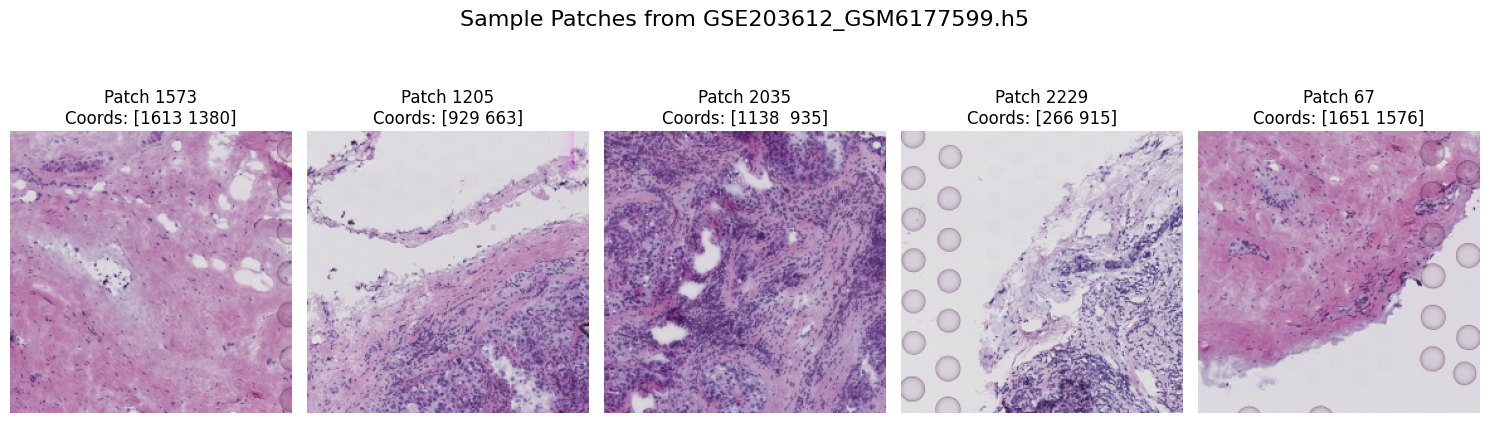

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
import random


# Define the HDF5 patches directory (from previous cell output)
H5_PATCHES_TRAIN_DIR = PROCESSED_PATCH_DIR / "train"

# Get a list of all HDF5 files in the train directory
h5_files = list(H5_PATCHES_TRAIN_DIR.glob("*.h5"))

if not h5_files:
    print(f"No HDF5 files found in {H5_PATCHES_TRAIN_DIR}. Please ensure patch extraction was successful.")
else:
    # Choose the first HDF5 file found for demonstration
    sample_h5_file = h5_files[0]
    print(f"Loading patches from: {sample_h5_file}")

    with h5py.File(sample_h5_file, 'r') as f:
        patches = f['patches']
        coords = f['coords']

        print(f"\nDataset 'patches' shape: {patches.shape} (num_spots, patch_size, patch_size, 3)")
        print(f"Dataset 'coords' shape:  {coords.shape} (num_spots, 2)")
        print(f"Number of patches extracted: {f.attrs['num_spots']}")
        print(f"Patch size: {f.attrs['patch_size']}x{f.attrs['patch_size']}")

        # Display a few random patches
        num_patches_to_display = min(5, patches.shape[0])
        if num_patches_to_display > 0:
            random_indices = random.sample(range(patches.shape[0]), num_patches_to_display)

            plt.figure(figsize=(15, 5))
            plt.suptitle(f"Sample Patches from {sample_h5_file.name}", fontsize=16)
            for i, idx in enumerate(random_indices):
                plt.subplot(1, num_patches_to_display, i + 1)
                plt.imshow(patches[idx])
                plt.title(f"Patch {idx}\nCoords: {coords[idx]}")
                plt.axis('off')
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

            # Store the patches for later saving example
            sample_patches_data = patches
            sample_coords_data = coords
            current_sample_name = sample_h5_file.stem

        else:
            print("No patches to display in this HDF5 file.")

Triggering debug visualization for sample: GSE203612_GSM6177599
  Debug: Image dimensions for GSE203612_GSM6177599: 1961x2000
  DEBUG VISUALIZATION for GSE203612_GSM6177599:


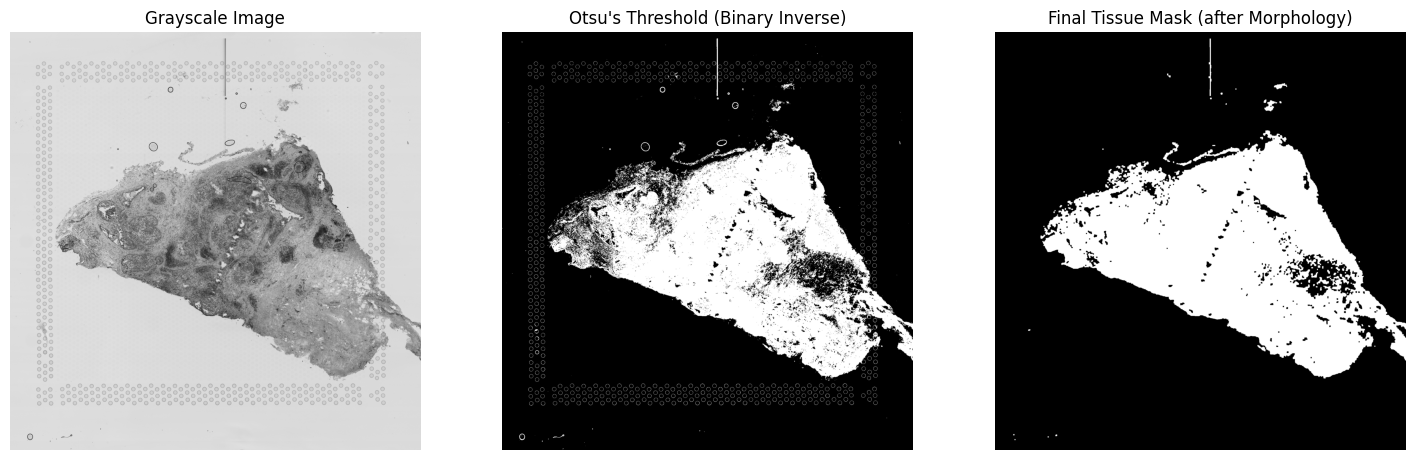

Debug visualization complete. (No HDF5 file was saved for this debug run)


In [ ]:

# Confirming if the tissue section was carried out

# --- Select a sample for visualization ---
# We'll use the first sample from the train set that was just processed.
# Make sure the 'RAW_DATA_DIR / "train"' path exists and contains samples.

raw_train_samples_path = RAW_DATA_DIR / "train"

if not raw_train_samples_path.exists():
    print(f"Error: Raw train data directory not found: {raw_train_samples_path}")
else:
    sample_folders_in_train = sorted([f for f in raw_train_samples_path.iterdir() if f.is_dir()])

    if not sample_folders_in_train:
        print(f"Error: No sample folders found in {raw_train_samples_path}")
    else:
        # Choose the first sample for debug visualization
        sample_to_visualize = sample_folders_in_train[0]
        sample_name_to_visualize = sample_to_visualize.name

        # Define a dummy output path for this single run
        # We won't actually save HDF5 for this debug visualization call
        dummy_output_h5_path = PROCESSED_PATCH_DIR / "temp_debug" / f"{sample_name_to_visualize}.h5"

        print(f"Triggering debug visualization for sample: {sample_name_to_visualize}")
        _ = extract_high_quality_patches(
            sample_dir=sample_to_visualize,
            output_h5_path=dummy_output_h5_path,
            patch_size=224,
            min_tissue_percent=0.35,
            debug_visualize=True # This is the key parameter!
        )
        print("Debug visualization complete. (No HDF5 file was saved for this debug run)")


== Analyzing Train Split HDF5 Patches ==
Loading coordinates from: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/patches/train/GSE203612_GSM6177599.h5

--- Analysis for GSE203612_GSM6177599 (Train split) ---
Coordinates shape: (2360, 2)
No NaN values detected in coordinates.
No negative coordinate values detected.
Minimum coordinate value: 247
Maximum coordinate value: 1689


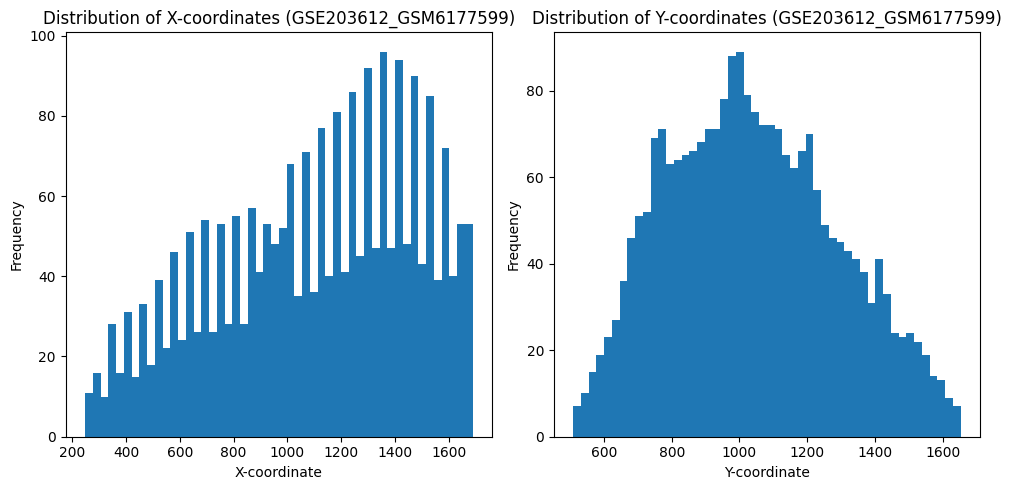

Based on the checks, coordinates appear to be free of NaNs and negative values.

== Analyzing Validation Split HDF5 Patches ==
Loading coordinates from: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/patches/val/Human_Breast_Andersson_10142021_ST_A2.h5

--- Analysis for Human_Breast_Andersson_10142021_ST_A2 (Validation split) ---
Coordinates shape: (286, 2)
No NaN values detected in coordinates.
No negative coordinate values detected.
Minimum coordinate value: 199
Maximum coordinate value: 6344


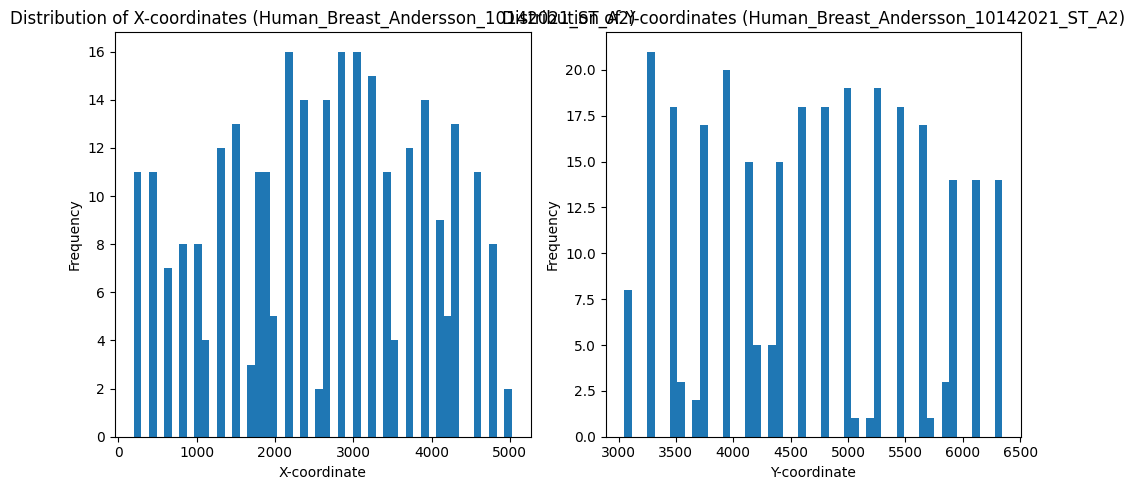

Based on the checks, coordinates appear to be free of NaNs and negative values.

== Analyzing Test Split HDF5 Patches ==
Loading coordinates from: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/patches/test/GSE212482_GSM6543813.h5

--- Analysis for GSE212482_GSM6543813 (Test split) ---
Coordinates shape: (1659, 2)
No NaN values detected in coordinates.
No negative coordinate values detected.
Minimum coordinate value: 334
Maximum coordinate value: 1713


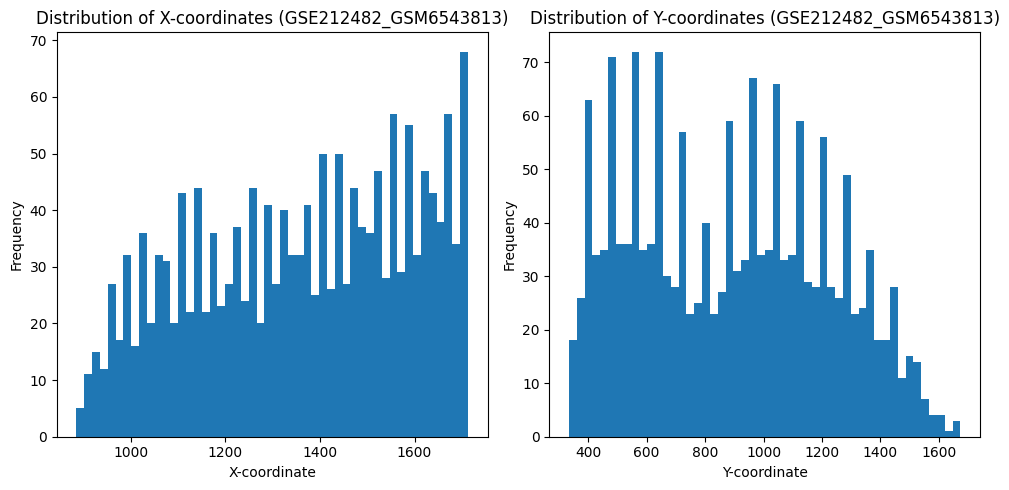

Based on the checks, coordinates appear to be free of NaNs and negative values.


In [ ]:
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Define the HDF5 patches directories (reusing definitions from uFNFUNzleIvN)
H5_PATCHES_TRAIN_DIR = PROCESSED_PATCH_DIR / "train"
H5_PATCHES_VAL_DIR = PROCESSED_PATCH_DIR / "val"
H5_PATCHES_TEST_DIR = PROCESSED_PATCH_DIR / "test"

# List of directories to process
processing_dirs = [
    (H5_PATCHES_TRAIN_DIR, "Train"),
    (H5_PATCHES_VAL_DIR, "Validation"),
    (H5_PATCHES_TEST_DIR, "Test")
]

for h5_dir, split_name in processing_dirs:
    print(f"\n== Analyzing {split_name} Split HDF5 Patches ==")

    if not h5_dir.exists():
        print(f"Directory not found: {h5_dir}. Skipping {split_name} split.")
        continue

    h5_files = list(h5_dir.glob("*.h5"))

    if not h5_files:
        print(f"No HDF5 files found in {h5_dir}. Please ensure patch extraction was successful for this split.")
        continue

    # Choose the first HDF5 file found for demonstration from each split
    sample_h5_file = h5_files[0]
    print(f"Loading coordinates from: {sample_h5_file}")

    with h5py.File(sample_h5_file, 'r') as f:
        coords_data = f['coords'][()] # Load all coordinates into memory
        sample_name = f.attrs['sample_name']

        print(f"\n--- Analysis for {sample_name} ({split_name} split) ---")
        print(f"Coordinates shape: {coords_data.shape}")

        # 1. Check for missing values (e.g., NaN, None)
        if np.isnan(coords_data).any():
            print("WARNING: Missing (NaN) values detected in coordinates!")
        else:
            print("No NaN values detected in coordinates.")

        # 2. Check for negative coordinates (anomalies)
        negative_coords = coords_data[coords_data < 0]
        if negative_coords.size > 0:
            print(f"WARNING: {negative_coords.size} negative coordinate values detected. Examples: {negative_coords[:5]}")
        else:
            print("No negative coordinate values detected.")

        # 3. Check coordinate ranges
        max_coord_val = np.max(coords_data)
        min_coord_val = np.min(coords_data)

        print(f"Minimum coordinate value: {min_coord_val}")
        print(f"Maximum coordinate value: {max_coord_val}")

        # Visualize coordinate distribution
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.hist(coords_data[:, 0], bins=50)
        plt.title(f'Distribution of X-coordinates ({sample_name})')
        plt.xlabel('X-coordinate')
        plt.ylabel('Frequency')

        plt.subplot(1, 2, 2)
        plt.hist(coords_data[:, 1], bins=50)
        plt.title(f'Distribution of Y-coordinates ({sample_name})')
        plt.xlabel('Y-coordinate')
        plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

        if not np.isnan(coords_data).any() and negative_coords.size == 0:
            print("Based on the checks, coordinates appear to be free of NaNs and negative values.")
        else:
            print("Please review the warnings above regarding coordinate data.")

In [ ]:
# Saving samples patches from all splits

import h5py
import numpy as np
from PIL import Image
from pathlib import Path
import random
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt # Import matplotlib

# Define output directory for general visualization patches
VISUALIZATION_PATCH_DIR = PROJECT_ROOT/ "visualizations"/ "Patch_extraction"
# Ensure the root visualization directory exists
VISUALIZATION_PATCH_DIR.mkdir(parents=True, exist_ok=True)

# HDF5 patches directories (reusing definitions from uFNFUNzleIvN or earlier cells)
H5_PATCHES_TRAIN_DIR_NORM = PROCESSED_DIR / "normalized_patches"/ "train"
H5_PATCHES_VAL_DIR_NORM = PROCESSED_DIR / "normalized_patches"/ "val"
H5_PATCHES_TEST_DIR_NORM = PROCESSED_DIR / "normalized_patches"/ "test"

# List of directories to process for visualization
processing_splits_for_viz = [
    (H5_PATCHES_TRAIN_DIR_NORM, "train"),
    (H5_PATCHES_VAL_DIR_NORM, "val"),
    (H5_PATCHES_TEST_DIR_NORM, "test")
]

NUM_RANDOM_PATCHES_PER_SAMPLE = 5 # Number of random patches to save per sample

for h5_dir, split_name in processing_splits_for_viz:
    print(f"\n== Processing HDF5 files in {split_name} split for visualization patches ==")

    if not h5_dir.exists():
        print(f"Directory not found: {h5_dir}. Skipping {split_name} split.")
        continue

    h5_files = list(h5_dir.glob("*.h5"))

    if not h5_files:
        print(f"No HDF5 files found in {h5_dir}. Skipping {split_name} split.")
        continue

    # Create a sub-directory for the current split within the visualization folder
    split_output_dir = VISUALIZATION_PATCH_DIR / split_name
    split_output_dir.mkdir(parents=True, exist_ok=True)

    for sample_h5_file in tqdm(h5_files, desc=f"Saving random patches for {split_name} split"):
        try:
            with h5py.File(sample_h5_file, 'r') as f:
                # Check if 'patches' and 'coords' are actual datasets
                if 'patches' not in f or not isinstance(f['patches'], h5py.Dataset):
                    print(f"  Warning: 'patches' dataset not found or invalid in {sample_h5_file}. Skipping.")
                    continue
                if 'coords' not in f or not isinstance(f['coords'], h5py.Dataset):
                    print(f"  Warning: 'coords' dataset not found or invalid in {sample_h5_file}. Skipping.")
                    continue

                patches_data = f['patches']
                coords_data = f['coords']
                sample_name = f.attrs['sample_name']

                num_patches_in_h5 = patches_data.shape[0]

                if num_patches_in_h5 == 0:
                    continue

                # Select random indices for patches to save
                indices_to_save = random.sample(range(num_patches_in_h5), min(NUM_RANDOM_PATCHES_PER_SAMPLE, num_patches_in_h5))

                # === Use matplotlib to create a mosaic image ===
                # Determine grid size for mosaic (single row)
                grid_rows = 1
                grid_cols = NUM_RANDOM_PATCHES_PER_SAMPLE

                # Adjust figure size for a horizontal layout
                fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(3 * NUM_RANDOM_PATCHES_PER_SAMPLE, 5))

                # Ensure axes is always an array, even for single patch
                if NUM_RANDOM_PATCHES_PER_SAMPLE == 1:
                    axes = [axes]
                else:
                    axes = axes.flatten() # Flatten in case of single row/col

                fig.suptitle(f"Sample Patches from {sample_name}", fontsize=16)

                for i, idx in enumerate(indices_to_save):
                    if i < len(axes):
                        ax = axes[i]
                        ax.imshow(patches_data[idx])
                        ax.set_title(f"Patch {idx}\nCoords: {coords_data[idx]}")
                        ax.axis('off')

                # Hide any unused subplots (if fewer patches than NUM_RANDOM_PATCHES_PER_SAMPLE)
                for j in range(len(indices_to_save), len(axes)):
                    axes[j].axis('off')

                plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle

                # Save the mosaic image directly into the split's output directory
                output_filename = split_output_dir / f"{sample_name}_random_patches_mosaic.png"
                # Explicitly ensure the parent directory exists right before saving the file.
                # This helps against potential filesystem delays or inconsistencies, especially on network drives.
                output_filename.parent.mkdir(parents=True, exist_ok=True)
                plt.savefig(str(output_filename), bbox_inches='tight', dpi=150)
                plt.close(fig) # Close the figure to free memory

        except Exception as e:
            print(f"  ERROR processing {sample_h5_file}: {e}. Skipping this file.")

print(f"\nFinished saving sample patches to: {VISUALIZATION_PATCH_DIR}")


== Processing HDF5 files in train split for visualization patches ==


Saving random patches for train split: 100%|██████████| 149/149 [07:49<00:00,  3.15s/it]



== Processing HDF5 files in val split for visualization patches ==


Saving random patches for val split: 100%|██████████| 28/28 [00:57<00:00,  2.06s/it]



== Processing HDF5 files in test split for visualization patches ==


Saving random patches for test split: 100%|██████████| 26/26 [01:06<00:00,  2.57s/it]


Finished saving sample patches to: /content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/Patch_extraction


## Macenko Stain Normalization (Using NormalizerBuilder)

After extracting the patches, we reduce **stain variation** across the different studies present in our dataset. Since the images come from multiple sources (e.g., `Human_Breast_He`, `Human_Breast_Andersson`, `GSE*` series, etc.), color differences can negatively affect model performance.

To address this, we apply **Macenko stain normalization**. Instead of using the older `StainNormalizer` class, we use the more modern and flexible `NormalizerBuilder` from the `torchstain` library.

### Approach:
- Select one high-quality reference image from the Training set.
- Use `NormalizerBuilder` to create and fit a Macenko normalizer on the reference image.
- Apply the fitted normalizer to all extracted patches (Train, Val, and Test).

This ensures that all patches are stain-normalized in a consistent and reproducible manner while preventing data leakage (the normalizer is fitted only on the Training set).

In [ ]:
# Import Required Libraries

!pip install torch-staintools

import torch
import torch_staintools
from torch_staintools.normalizer import NormalizerBuilder
from torchvision import transforms
from PIL import Image
from pathlib import Path
import pickle
import numpy as np

In [ ]:
# Define Paths and Load Reference Image

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "train"

# Choose your reference image from the Training set
# You can change this to any good-looking sample in the train folder
REFERENCE_SAMPLE = "GSE210616_GSM6433586"   # ← Change to your chosen reference sample name
REFERENCE_IMAGE_PATH = TRAIN_DIR / REFERENCE_SAMPLE / f"{REFERENCE_SAMPLE}.png"

print(f"Reference image path: {REFERENCE_IMAGE_PATH}")
print(f"File exists: {REFERENCE_IMAGE_PATH.exists()}")
# ===================================================

# Load the full reference image
ref_img = Image.open(REFERENCE_IMAGE_PATH).convert("RGB")
print(f"Reference image size: {ref_img.size}")

Reference image path: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/raw/train/GSE210616_GSM6433586/GSE210616_GSM6433586.png
File exists: True
Reference image size: (2000, 1929)


In [ ]:
# Build the Macenko normalizer
normalizer = NormalizerBuilder.build(
    method='macenko',                # or 'vahadane', 'reinhard'
    concentration_solver='qr',       # recommended; alternatives: 'pinv', 'ls'
    use_cache=True                   # enables caching for speed if normalizing many images
)

print("Normalizer built successfully!")

Normalizer built successfully!


In [ ]:
# Convert to torch tensor (B=1, C=3, H, W) in [0., 1.]
ref_tensor = torch.from_numpy(np.array(ref_img)).permute(2, 0, 1).unsqueeze(0).float() / 255.0

# Move to GPU if available (recommended for speed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
normalizer = normalizer.to(device)
ref_tensor = ref_tensor.to(device)

# Fit on reference image
normalizer.fit(ref_tensor)

print("Fitted on reference!")

# Define the full path for the normalizer file
normalizer_save_path = PROJECT_ROOT / "data" / "processed" / "macenko_normalizer.pkl"
normalizer_save_path.parent.mkdir(parents=True, exist_ok=True)

# Save the fitted normalizer
with open(normalizer_save_path, "wb") as f:
    pickle.dump(normalizer, f)

print(f"Fitted normalizer saved to: {normalizer_save_path}")

Fitted on reference!
Fitted normalizer saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/macenko_normalizer.pkl


In [ ]:
# Load the saved Normalizer

import pickle
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
NORMALIZER_PATH = PROJECT_ROOT / "data" / "processed" / "macenko_normalizer.pkl"

with open(NORMALIZER_PATH, "rb") as f:
    normalizer = pickle.load(f)

print("✅ Macenko normalizer loaded successfully!")

✅ Macenko normalizer loaded successfully!


In [ ]:
import h5py
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from pathlib import Path
import torch

def normalize_patches_in_h5(input_h5_path, output_h5_path, normalizer):
    """
    Load patches from an existing .h5 file, apply Macenko normalization,
    and save the normalized patches to a new .h5 file.
    """
    input_h5_path = Path(input_h5_path)
    output_h5_path = Path(output_h5_path)

    with h5py.File(input_h5_path, 'r') as f_in:
        patches = f_in['patches'][:]           # (N, 224, 224, 3)
        coords = f_in['coords'][:]             # (N, 2)
        attrs = dict(f_in.attrs)

    # Explicitly check for empty patches array
    if patches.shape[0] == 0:
        print(f"  Warning: No patches found in {input_h5_path.name}. Skipping normalization for this sample.")
        # Create an empty HDF5 file to signify it was processed but had no patches
        output_h5_path.parent.mkdir(parents=True, exist_ok=True)
        with h5py.File(output_h5_path, 'w') as f_out:
            f_out.create_dataset('patches', data=np.array([], dtype=np.uint8).reshape(0, 224, 224, 3), compression='gzip')
            f_out.create_dataset('coords', data=np.array([], dtype=np.int32).reshape(0, 2), compression='gzip')
            for key, value in attrs.items():
                f_out.attrs[key] = value
            f_out.attrs['macenko_normalized'] = True
            f_out.attrs['num_spots'] = 0
        return 0

    to_tensor = transforms.ToTensor()
    normalized_patches = []
    valid_coords = [] # Keep track of coords for successfully normalized patches

    # Move the normalizer to the correct device once
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    normalizer = normalizer.to(device)
    normalizer.eval() # Set normalizer to evaluation mode if it's a torch.nn.Module

    for idx, patch in enumerate(patches):
        try:
            # Convert to tensor: (1, 3, H, W) and move to device
            patch_tensor = to_tensor(patch).unsqueeze(0).to(device)

            # Apply normalization using .transform()
            result = normalizer.transform(patch_tensor)
            if isinstance(result, (list, tuple)):
                norm_tensor = result[0]
            else:
                norm_tensor = result

            # Convert back to uint8 numpy array and move to CPU if necessary
            norm_patch = (norm_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            normalized_patches.append(norm_patch)
            valid_coords.append(coords[idx])
        except Exception as e:
            print(f"  Warning: Failed to normalize patch {idx} from {input_h5_path.name}: {e}. Skipping this patch.")
            # This specific error might come from torchstain if no tissue is found in the patch.
            # We just skip the patch and continue.

    normalized_patches = np.array(normalized_patches, dtype=np.uint8)
    valid_coords = np.array(valid_coords, dtype=np.int32)

    # Save to new .h5 file
    output_h5_path.parent.mkdir(parents=True, exist_ok=True)

    with h5py.File(output_h5_path, 'w') as f_out:
        f_out.create_dataset('patches', data=normalized_patches, compression='gzip')
        f_out.create_dataset('coords', data=valid_coords, compression='gzip')

        # Copy original metadata
        for key, value in attrs.items():
            f_out.attrs[key] = value

        f_out.attrs['macenko_normalized'] = True
        f_out.attrs['num_spots'] = len(normalized_patches)

    return len(normalized_patches)

In [ ]:
import pickle
from tqdm import tqdm
from pathlib import Path
import h5py # Import h5py

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ORIGINAL_PATCHES_DIR = PROCESSED_DIR / "patches"
NORMALIZED_PATCHES_DIR = PROCESSED_DIR / "normalized_patches"


# Ensure the parent directory for normalized patches exists
NORMALIZED_PATCHES_DIR.mkdir(parents=True, exist_ok=True)

splits = ["train", "val", "test"]
total_normalized = 0

print("Starting Macenko normalization for all splits...")

for split in splits:
    input_dir = ORIGINAL_PATCHES_DIR / split
    output_dir = NORMALIZED_PATCHES_DIR / split

    h5_files = sorted(list(input_dir.glob("*.h5")))

    for h5_file in tqdm(h5_files, desc=f"Normalizing {split} split"):
        output_h5_path = output_dir / h5_file.name

        # Check if the normalized HDF5 file already exists and is complete
        if output_h5_path.exists():
            try:
                with h5py.File(output_h5_path, 'r') as f_h5_norm:
                    # A file is considered 'normalized' if it has the 'macenko_normalized' attribute set to True
                    # and contains 'num_spots' to count correctly.
                    if f_h5_norm.attrs.get('macenko_normalized', False) and 'num_spots' in f_h5_norm.attrs:
                        current_num_spots = f_h5_norm.attrs['num_spots']
                        total_normalized += current_num_spots
                        # print(f"  Skipping '{h5_file.name}': Normalized HDF5 file already exists.") # Optional verbose message
                        continue # Move to the next HDF5 file
            except Exception:
                # If reading fails, it implies the file is corrupted or incomplete, so it will be reprocessed.
                pass # No explicit action needed, just fall through to reprocessing

        try:
            num = normalize_patches_in_h5(
                input_h5_path=h5_file,
                output_h5_path=output_h5_path,
                normalizer=normalizer
            )
            total_normalized += num
        except Exception as e:
            print(f"\n❌ Failed to normalize '{h5_file.name}': {e}\n") # Added newline for better readability of error messages

print(f"\n✅ Macenko normalization completed!")
print(f"Total patches normalized: {total_normalized}")
print(f"Normalized patches saved in: {NORMALIZED_PATCHES_DIR}")

Starting Macenko normalization for all splits...


Normalizing test split:  46%|████▌     | 12/26 [09:44<11:59, 51.37s/it]


❌ Failed to normalize 'GSE242311_GSM7757971.h5': Empty tissue mask computed



Normalizing test split: 100%|██████████| 26/26 [27:50<00:00, 64.24s/it]


✅ Macenko normalization completed!
Total patches normalized: 199449
Normalized patches saved in: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/normalized_patches


In [ ]:
# Saving normalized patches as images

import h5py
import numpy as np
from PIL import Image
from pathlib import Path
import random
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt # Import matplotlib

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

NORMALIZED_PATCHES_DIR = PROCESSED_DIR / "normalized_patches"

# Define output directory for general visualization patches
VISUALIZATION_PATCH_DIR = PROJECT_ROOT/ "visualizations"/ "Patch_extraction"
# Ensure the root visualization directory exists
VISUALIZATION_PATCH_DIR.mkdir(parents=True, exist_ok=True)


# List of directories to process for visualization
processing_splits_for_viz = [
    (NORMALIZED_PATCHES_DIR / "train", "train"),
    (NORMALIZED_PATCHES_DIR / "val", "val"),
    (NORMALIZED_PATCHES_DIR / "test", "test")
]

NUM_RANDOM_PATCHES_PER_SAMPLE = 5 # Number of random patches to save per sample

for h5_dir, split_name in processing_splits_for_viz:
    print(f"\n== Processing HDF5 files in {split_name} split for visualization patches ==")

    if not h5_dir.exists():
        print(f"Directory not found: {h5_dir}. Skipping {split_name} split.")
        continue

    h5_files = list(h5_dir.glob("*.h5"))

    if not h5_files:
        print(f"No HDF5 files found in {h5_dir}. Skipping {split_name} split.")
        continue

    # Create a sub-directory for the current split within the visualization folder
    split_output_dir = VISUALIZATION_PATCH_DIR / split_name
    split_output_dir.mkdir(parents=True, exist_ok=True)

    for sample_h5_file in tqdm(h5_files, desc=f"Saving random patches for {split_name} split"):
        try:
            with h5py.File(sample_h5_file, 'r') as f:
                # Check if 'patches' and 'coords' are actual datasets
                if 'patches' not in f or not isinstance(f['patches'], h5py.Dataset):
                    print(f"  Warning: 'patches' dataset not found or invalid in {sample_h5_file}. Skipping.")
                    continue
                if 'coords' not in f or not isinstance(f['coords'], h5py.Dataset):
                    print(f"  Warning: 'coords' dataset not found or invalid in {sample_h5_file}. Skipping.")
                    continue

                patches_data = f['patches']
                coords_data = f['coords']
                sample_name = f.attrs['sample_name']

                num_patches_in_h5 = patches_data.shape[0]

                if num_patches_in_h5 == 0:
                    continue

                # Select random indices for patches to save
                indices_to_save = random.sample(range(num_patches_in_h5), min(NUM_RANDOM_PATCHES_PER_SAMPLE, num_patches_in_h5))

                # === Use matplotlib to create a mosaic image ===
                # Determine grid size for mosaic (single row)
                grid_rows = 1
                grid_cols = NUM_RANDOM_PATCHES_PER_SAMPLE

                # Adjust figure size for a horizontal layout
                fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(3 * NUM_RANDOM_PATCHES_PER_SAMPLE, 5))

                # Ensure axes is always an array, even for single patch
                if NUM_RANDOM_PATCHES_PER_SAMPLE == 1:
                    axes = [axes]
                else:
                    axes = axes.flatten() # Flatten in case of single row/col

                fig.suptitle(f"Sample Patches from {sample_name}", fontsize=16)

                for i, idx in enumerate(indices_to_save):
                    if i < len(axes):
                        ax = axes[i]
                        ax.imshow(patches_data[idx])
                        ax.set_title(f"Patch {idx}\nCoords: {coords_data[idx]}")
                        ax.axis('off')

                # Hide any unused subplots (if fewer patches than NUM_RANDOM_PATCHES_PER_SAMPLE)
                for j in range(len(indices_to_save), len(axes)):
                    axes[j].axis('off')

                plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle

                # Save the mosaic image directly into the split's output directory
                output_filename = split_output_dir / f"{sample_name}_random_patches_mosaic.png"
                # Explicitly ensure the parent directory exists right before saving the file.
                # This helps against potential filesystem delays or inconsistencies, especially on network drives.
                output_filename.parent.mkdir(parents=True, exist_ok=True)
                plt.savefig(str(output_filename), bbox_inches='tight', dpi=1200) # Increased DPI for higher quality
                plt.close(fig) # Close the figure to free memory

        except Exception as e:
            print(f"  ERROR processing {sample_h5_file}: {e}. Skipping this file.")

print(f"\nFinished saving sample patches to: {VISUALIZATION_PATCH_DIR}")


== Processing HDF5 files in train split for visualization patches ==


Saving random patches for train split: 100%|██████████| 149/149 [12:14<00:00,  4.93s/it]



== Processing HDF5 files in val split for visualization patches ==


Saving random patches for val split: 100%|██████████| 28/28 [02:07<00:00,  4.56s/it]



== Processing HDF5 files in test split for visualization patches ==


Saving random patches for test split: 100%|██████████| 25/25 [02:07<00:00,  5.09s/it]


Finished saving sample patches to: /content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/Patch_extraction


## 2.3 Spatial Transcriptomics Preprocessing

### Objectives:
- Load gene expression data for all samples
- Perform quality control (filter low-quality spots and genes)
- Normalize the data
- Identify Highly Variable Genes (**computed only on the Training set** to prevent data leakage)
- Construct spatial neighbor graphs for each sample
- Save the processed data in a structured and reproducible format

This preprocessing ensures that the gene expression data is clean, consistent, and ready for multimodal fusion with the image features.

In [ ]:
!pip install scanpy
!pip install squidpy
!pip install scikit-misc

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import scanpy as sc
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_ST_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed"


PROCESSED_ST_DIR.mkdir(parents=True, exist_ok=True)

# Load split information from the saved CSV files
train_samples = pd.read_csv(RAW_DATA_DIR / "train_slides.csv")['slide'].tolist()
val_samples   = pd.read_csv(RAW_DATA_DIR / "val_slides.csv")['slide'].tolist()
test_samples  = pd.read_csv(RAW_DATA_DIR / "test_slides.csv")['slide'].tolist()

print(f"Train samples: {len(train_samples)}")
print(f"Val samples  : {len(val_samples)}")
print(f"Test samples : {len(test_samples)}")

Train samples: 150
Val samples  : 27
Test samples : 25


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
from tqdm import tqdm
import pickle
from typing import List, Optional, Dict
from sklearn.neighbors import kneighbors_graph
import warnings
import sys # Added for memory monitoring
import gc # Added for garbage collection
warnings.filterwarnings("ignore")


# ============================================================
# 1. Load One Sample
# ============================================================
def load_st_sample(sample_name: str, raw_data_base_dir: Path) -> sc.AnnData:
    """Load a single sample into AnnData."""
    sample_path = Path(raw_data_base_dir) / sample_name

    # Load counts
    counts_path = sample_path / f"{sample_name}_count.csv"
    if not counts_path.exists():
        counts_path = list(sample_path.glob("*count*.csv"))[0]
    counts_df = pd.read_csv(counts_path, index_col=0)

    # Load coordinates
    coord_path = sample_path / f"{sample_name}_coord.csv"
    if not coord_path.exists():
        coord_path = list(sample_path.glob("*_coord.csv"))[0]
    coords_df = pd.read_csv(coord_path)

    # Create AnnData
    adata = sc.AnnData(X=counts_df.values)
    adata.obs_names = counts_df.index.astype(str)
    adata.var_names = counts_df.columns.astype(str)

    # Add spatial coordinates
    if {'x', 'y'}.issubset(coords_df.columns):
        adata.obsm['spatial'] = coords_df[['x', 'y']].values
    elif {'xaxis', 'yaxis'}.issubset(coords_df.columns):
        adata.obsm['spatial'] = coords_df[['xaxis', 'yaxis']].values
    else:
        raise ValueError(f"No spatial coordinates found for {sample_name}")

    adata.obs['sample'] = sample_name
    adata.var_names_make_unique()

    return adata


# ============================================================
# 2. Load Multiple Samples
# ============================================================
def load_multiple_st_samples(sample_list: List[str], raw_data_base_dir: Path) -> Dict[str, sc.AnnData]:
    """Load multiple samples into a dictionary."""
    adata_dict = {}
    for sample_name in tqdm(sample_list, desc="Loading samples"):
        try:
            adata = load_st_sample(sample_name, raw_data_base_dir)
            adata_dict[sample_name] = adata
        except Exception as e:
            print(f"Failed to load {sample_name}: {e}")
    return adata_dict


# ============================================================
# 3. Quality Control
# ============================================================
def run_quality_control(
    adata: sc.AnnData,
    min_genes: int = 200,
    min_cells: int = 3,
    max_mt_percent: float = 20.0
) -> sc.AnnData:
    """Perform quality control."""
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)

    # Mitochondrial content
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

    adata = adata[adata.obs['pct_counts_mt'] < max_mt_percent, :].copy()
    return adata


# ============================================================
# 4. Normalization
# ============================================================
def normalize_data(adata: sc.AnnData, target_sum: float = 1e4) -> sc.AnnData:
    """Total count normalization + log1p."""
    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)
    return adata


# ============================================================
# 5. Compute Global HVGs (from all training samples)
# ============================================================
def compute_global_hvgs(
    adata_dict: Dict[str, sc.AnnData],
    n_top_genes: int = 2000
) -> List[str]:
    """Compute HVGs from ALL training samples combined."""
    print("Computing global HVGs from all training samples combined...")
    print(f"  Current memory usage before concat: {sys.getsizeof(adata_dict) / (1024**3):.2f} GB (approx.)")

    adatas = list(adata_dict.values())

    if not adatas:
        print("  Warning: No AnnData objects in dictionary. Cannot compute HVGs.")
        return []

    combined = sc.concat(adatas, join='outer', index_unique=None)
    combined.var_names_make_unique()

    # Explicitly clear adatas list and run garbage collection
    del adatas
    gc.collect()
    print(f"  Memory freed after concat and del adatas. Combined object size: {sys.getsizeof(combined) / (1024**3):.2f} GB (approx.)")

    if combined.n_obs == 0 or combined.n_vars == 0:
        print("  Warning: Combined data is empty after concatenation. Cannot compute HVGs.")
        return []

    if combined.n_obs < 50 or combined.n_vars < 500:
        print("  Warning: Combined data too small for robust HVG computation. Using all genes as HVGs.")
        hvgs = combined.var_names.tolist()
    else:
        sc.pp.highly_variable_genes(
            combined,
            n_top_genes=n_top_genes,
            flavor='seurat_v3',
            min_mean=0.0125,
            max_mean=3,
            min_disp=0.5
        )
        hvgs = combined.var_names[combined.var.highly_variable].tolist()

    print(f"Computed {len(hvgs)} global HVGs.")
    return hvgs


# ============================================================
# 6. Build KNN Spatial Graph (Explicit)
# ============================================================
def build_knn_spatial_graph(adata: sc.AnnData, n_neighbors: int = 6) -> sc.AnnData:
    """Build an explicit KNN spatial graph."""
    if 'spatial' not in adata.obsm:
        raise ValueError("No spatial coordinates found in adata.obsm['spatial']")

    coords = adata.obsm['spatial']
    knn_graph = kneighbors_graph(
        coords,
        n_neighbors=n_neighbors,
        mode='connectivity',
        include_self=False
    )

    adata.obsp['spatial_connectivities'] = knn_graph
    adata.obsp['spatial_distances'] = kneighbors_graph(
        coords, n_neighbors=n_neighbors, mode='distance', include_self=False
    )

    adata.uns['spatial_graph_params'] = {
        'method': 'knn',
        'n_neighbors': n_neighbors
    }

    return adata


# ============================================================
# NEW: Compute HVGs from .h5ad files in batches (Memory Efficient)
# ============================================================
def compute_hvgs_from_file_batches(
    file_paths: List[str],
    n_top_genes: int = 2000,
    n_batches: int = 6
) -> List[str]:
    """
    Compute Highly Variable Genes from a list of .h5ad files in batches.
    This is more memory efficient for large datasets.
    """
    if not file_paths:
        raise ValueError("No file paths provided.")

    total_files = len(file_paths)
    batch_size = (total_files + n_batches - 1) // n_batches

    print(f"Total files: {total_files}")
    print(f"Splitting into {n_batches} batches (~{batch_size} files per batch)\n")

    all_batch_hvgs = []

    for i in range(n_batches):
        start = i * batch_size
        end = min((i + 1) * batch_size, total_files)
        current_batch = file_paths[start:end]

        if not current_batch:
            continue

        print(f"{'='*60}")
        print(f"Processing HVG Batch {i+1}/{n_batches} ({len(current_batch)} files)")
        print('='*60)

        adatas = []
        for path in tqdm(current_batch, desc=f"Batch {i+1}"):
            try:
                adata = sc.read_h5ad(path)
                adata.var_names_make_unique()
                adatas.append(adata)
            except Exception as e:
                print(f"  Failed to load {path}: {e}")

        if not adatas:
            print(f"  Skipping empty batch {i+1}")
            continue

        combined = sc.concat(adatas, join='outer', index_unique=None)
        combined.var_names_make_unique()

        print(f"  Combined batch {i+1}: {combined.n_obs} cells, {combined.n_vars} genes")

        sc.pp.highly_variable_genes(
            combined,
            n_top_genes=n_top_genes,
            flavor='seurat_v3',
            min_mean=0.0125,
            max_mean=3,
            min_disp=0.5
        )

        batch_hvgs = combined.var_names[combined.var.highly_variable].tolist()
        all_batch_hvgs.append(batch_hvgs)

        print(f"  Batch {i+1} HVGs: {len(batch_hvgs)}")

        del adatas, combined
        gc.collect()

    # Final selection from union of all batches
    from collections import Counter
    all_genes = []
    for hvgs in all_batch_hvgs:
        all_genes.extend(hvgs)

    gene_counts = Counter(all_genes)
    final_hvgs = [gene for gene, count in gene_counts.most_common(n_top_genes)]

    print(f"\nFinal selected HVGs after combining batches: {len(final_hvgs)}")
    return final_hvgs


# ============================================================
# 7. Main Preprocessing Function for One Split
# ============================================================
def preprocess_st_split(
    adata_dict: Dict[str, sc.AnnData],
    split_name: str,
    hvgs: Optional[List[str]] = None,
    min_genes: int = 200,
    min_cells: int = 3,
    n_top_hvgs: int = 2000,
    n_neighbors_spatial: int = 6,
    output_dir: Optional[Path] = None
) -> Dict[str, sc.AnnData]:
    """
    Full preprocessing pipeline for one split.
    """
    processed_dict = {}

    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*65}")
    print(f"Preprocessing {split_name.upper()} split ({len(adata_dict)} samples)")
    print('='*65)

    for sample_name, adata in tqdm(adata_dict.items(), desc=f"Processing {split_name}"):
        try:
            out_path = None
            if output_dir:
                out_path = output_dir / f"{sample_name}.h5ad"
                if out_path.exists():
                    print(f"  Loading pre-existing processed file for {sample_name}.")
                    processed_dict[sample_name] = sc.read_h5ad(out_path)
                    continue # Skip reprocessing this sample

            # QC
            adata = run_quality_control(adata, min_genes=min_genes, min_cells=min_cells)
            if adata.n_obs == 0:
                print(f"  Warning: {sample_name} has no observations after QC. Skipping.")
                continue

            # Normalization
            adata = normalize_data(adata)

            # HVG subsetting for for all splits
            if hvgs is not None:
                common_hvgs = [g for g in hvgs if g in adata.var_names]
                if len(common_hvgs) >= 500: # Use a reasonable threshold for common HVGs
                    adata = adata[:, common_hvgs].copy()
                    print(f"  Subsetted {sample_name} to {len(common_hvgs)} HVGs")
                else:
                    print(f"  Warning: Low HVG overlap for {sample_name} ({len(common_hvgs)}). Keeping full genes.")

            # Build KNN Spatial Graph
            adata = build_knn_spatial_graph(adata, n_neighbors=n_neighbors_spatial)

            processed_dict[sample_name] = adata

            # Save as .h5ad
            if out_path:
                adata.write_h5ad(out_path)

        except Exception as e:
            print(f"ERROR processing {sample_name}: {e}")
            continue

    return processed_dict

    # ============================================================
# NEW FUNCTION: Subset already processed .h5ad files to HVGs
# ============================================================
def subset_h5ad_files_to_hvgs(
    file_paths: List[str],
    hvgs: List[str],
    output_dir: str,
    min_common_hvgs: int = 500
) -> None:
    """
    Subset a list of .h5ad files to a given list of HVGs and save them.

    This function is useful when you already have processed .h5ad files
    and only want to filter them to the final set of HVGs.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Subsetting {len(file_paths)} files to {len(hvgs)} HVGs...")

    for file_path in tqdm(file_paths, desc="Subsetting files"):
        try:
            adata = sc.read_h5ad(file_path)
            adata.var_names_make_unique()

            # Keep only genes that exist in both the file and the HVGs list
            common_genes = [g for g in hvgs if g in adata.var_names]

            if len(common_genes) < min_common_hvgs:
                print(f"  Skipping {Path(file_path).name} — only {len(common_genes)} overlapping genes")
                continue

            # Subset the AnnData object
            adata = adata[:, common_genes].copy()

            # Save the subsetted file
            output_name = Path(file_path).name
            output_path = output_dir / output_name
            adata.write_h5ad(output_path)

            # Clear from memory
            del adata
            gc.collect()

        except Exception as e:
            print(f"  ERROR processing {Path(file_path).name}: {e}")
            continue

    print(f"\n✅ Subsetting completed. Files saved to: {output_dir}")

### Full Preprocessing Pipeline (All Samples)

This cell executes the full preprocessing pipeline across all samples in the training, validation, and test sets. It processes each sample according to the defined steps: Quality Control, Normalization, HVG selection (for validation/test sets based on global HVGs from training), and spatial graph construction.

The results for each sample are saved as `.h5ad` files in their respective output directories and a summary of processed samples is printed.

In [ ]:
from pathlib import Path
import pickle

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
NORMALIZED_TRAIN_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train1"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed"
# ====================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Get all normalized training files
train_files = sorted(list(NORMALIZED_TRAIN_DIR.glob("*.h5ad")))
print(f"Found {len(train_files)} normalized training files.")

# Compute HVGs batch by batch
final_hvgs = compute_hvgs_from_file_batches(
    file_paths=train_files,
    n_top_genes=2000,
    n_batches=6
)

# Save final HVGs
hvg_path = OUTPUT_DIR / "hvgs_train.pkl"
with open(hvg_path, "wb") as f:
    pickle.dump(final_hvgs, f)

print(f"\n✅ Final {len(final_hvgs)} HVGs saved to: {hvg_path}")

Found 150 normalized training files.
Total files: 150
Splitting into 6 batches (~25 files per batch)

Processing HVG Batch 1/6 (25 files)


Batch 1: 100%|██████████| 25/25 [01:57<00:00,  4.70s/it]


  Combined batch 1: 33753 cells, 27083 genes
  Batch 1 HVGs: 2000
Processing HVG Batch 2/6 (25 files)


Batch 2: 100%|██████████| 25/25 [01:33<00:00,  3.72s/it]


  Combined batch 2: 35522 cells, 25341 genes
  Batch 2 HVGs: 2000
Processing HVG Batch 3/6 (25 files)


...

  Combined batch 4: 11391 cells, 16614 genes
  Batch 4 HVGs: 2000
Processing HVG Batch 5/6 (25 files)


Batch 5: 100%|██████████| 25/25 [00:29<00:00,  1.20s/it]


  Combined batch 5: 11807 cells, 17260 genes
  Batch 5 HVGs: 2000
Processing HVG Batch 6/6 (25 files)


Batch 6: 100%|██████████| 25/25 [00:43<00:00,  1.73s/it]


  Combined batch 6: 20941 cells, 24704 genes
  Batch 6 HVGs: 2000

Final selected HVGs after combining batches: 2000

✅ Final 2000 HVGs saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/hvgs_train.pkl


In [ ]:
from pathlib import Path
import pickle

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")

NORMALIZED_TRAIN_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train1"
SUBSETTED_TRAIN_DIR  = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train"
HVG_PATH             = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "hvgs_train.pkl"
# ====================================================

# Load final HVGs
with open(HVG_PATH, "rb") as f:
    final_hvgs = pickle.load(f)

print(f"Loaded {len(final_hvgs)} final HVGs.")

# Get all normalized training files
train_files = sorted(list(NORMALIZED_TRAIN_DIR.glob("*.h5ad")))
print(f"Found {len(train_files)} training files to subset.")

# Subset the files to the final HVGs
subset_h5ad_files_to_hvgs(
    file_paths=train_files,
    hvgs=final_hvgs,
    output_dir=SUBSETTED_TRAIN_DIR,
    min_common_hvgs=500
)

Loaded 2000 final HVGs.
Found 150 training files to subset.
Subsetting 150 files to 2000 HVGs...


Subsetting files: 100%|██████████| 150/150 [03:35<00:00,  1.43s/it]


✅ Subsetting completed. Files saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/train


In [ ]:
from pathlib import Path
import pickle

PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")

# Path to the final HVGs
HVG_PATH = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "hvgs_train.pkl"

with open(HVG_PATH, "rb") as f:
    global_hvgs = pickle.load(f)

print(f"Loaded {len(global_hvgs)} global HVGs from training set.")

Loaded 2000 global HVGs from training set.


### Process Validation Set

In [ ]:
from pathlib import Path

# Load Paths
PROCESSED_VAL_DIR = PROCESSED_ST_DIR / "val"
HVG_PATH        = PROCESSED_ST_DIR / "hvgs_train.pkl"
# ====================================================

# Load HVGs
with open(HVG_PATH, "rb") as f:
    global_hvgs = pickle.load(f)

# Load Validation samples from raw data
val_samples = pd.read_csv(RAW_DATA_DIR / "val_slides.csv")["slide"].tolist()

print(f"Processing {len(val_samples)} Validation samples...")

val_adata_dict = load_multiple_st_samples(val_samples, RAW_DATA_DIR/'val')

# Process Validation set using the global HVGs from training
processed_val = preprocess_st_split(
    adata_dict=val_adata_dict,
    split_name="val",
    hvgs=global_hvgs,                    # ← Use global HVGs from training
    min_genes=200,
    min_cells=3,
    n_neighbors_spatial=6,
    output_dir=PROCESSED_VAL_DIR
)

print(f"\n✅ Validation set processed: {len(processed_val)} samples")
print(f"Saved to: {PROCESSED_VAL_DIR}")

Processing 27 Validation samples...


Loading samples: 100%|██████████| 27/27 [00:54<00:00,  2.02s/it]



Preprocessing VAL split (27 samples)


Processing val:   4%|▎         | 1/27 [00:00<00:17,  1.49it/s]

  Subsetted Human_Breast_Andersson_10142021_ST_A2 to 1873 HVGs


...

  Subsetted Human_Breast_Andersson_10142021_ST_G3 to 1890 HVGs


Processing val:  96%|█████████▋| 26/27 [00:14<00:00,  1.42it/s]

  Subsetted Human_Breast_Andersson_10142021_ST_H2 to 1858 HVGs


Processing val: 100%|██████████| 27/27 [00:15<00:00,  1.79it/s]

  Subsetted Human_Breast_Andersson_10142021_ST_H3 to 1842 HVGs

✅ Validation set processed: 27 samples
Saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/val


### Process Test Set

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")

# ====================== PATHS ======================
# Load Paths
PROCESSED_TEST_DIR = PROCESSED_ST_DIR / "test"
HVG_PATH        = PROCESSED_ST_DIR / "hvgs_train.pkl"
# ====================================================

# Load HVGs
with open(HVG_PATH, "rb") as f:
    global_hvgs = pickle.load(f)

# Load Test samples from raw data
test_samples = pd.read_csv(RAW_DATA_DIR / "test_slides.csv")["slide"].tolist()

print(f"Processing {len(test_samples)} Test samples...")

test_adata_dict = load_multiple_st_samples(test_samples, RAW_DATA_DIR/'test')

# Process Test set using the global HVGs from training
processed_test = preprocess_st_split(
    adata_dict=test_adata_dict,
    split_name="test",
    hvgs=global_hvgs,                    # ← Use global HVGs from training
    min_genes=200,
    min_cells=3,
    n_neighbors_spatial=6,
    output_dir=PROCESSED_TEST_DIR
)

print(f"\n✅ Test set processed: {len(processed_test)} samples")
print(f"Saved to: {PROCESSED_TEST_DIR}")

Processing 25 Test samples...


Loading samples: 100%|██████████| 25/25 [22:42<00:00, 54.52s/it]



Preprocessing TEST split (25 samples)


Processing test:   0%|          | 0/25 [00:00<?, ?it/s]

Processing test:   4%|▍         | 1/25 [00:01<00:28,  1.18s/it]

...

  Subsetted GSE242311_GSM7757983 to 1904 HVGs


Processing test:  96%|█████████▌| 24/25 [02:09<00:04,  4.59s/it]

  Subsetted GSE242311_GSM7757984 to 1901 HVGs
  Subsetted GSE242311_GSM7757985 to 1906 HVGs


Processing test: 100%|██████████| 25/25 [02:15<00:00,  5.41s/it]


✅ Test set processed: 25 samples
Saved to: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/test


### Exploring the processed files

In [ ]:
from pathlib import Path
import scanpy as sc
from tqdm import tqdm
import numpy as np

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
SUBSETTED_TRAIN_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train"
# ====================================================

# Get all processed training files
train_files = sorted(list(SUBSETTED_TRAIN_DIR.glob("*.h5ad")))
print(f"Total processed training samples: {len(train_files)}\n")

if len(train_files) == 0:
    print("No files found. Please check the path.")
else:
    # Explore a few samples (first 3)
    sample_files = train_files[:3]

    for file_path in sample_files:
        print(f"{'='*70}")
        print(f"Exploring: {file_path.name}")
        print('='*70)

        adata = sc.read_h5ad(file_path)

        print(f"Shape (spots × genes): {adata.shape}")
        print(f"Number of genes        : {adata.n_vars}")
        print(f"Number of spots        : {adata.n_obs}")

        # Check if it looks like it was subsetted to HVGs
        print(f"\nExpected ~2000 genes?  : {'Yes' if 1500 <= adata.n_vars <= 2500 else 'No'}")

        # Check for spatial coordinates
        has_spatial = 'spatial' in adata.obsm
        print(f"Has spatial coordinates: {has_spatial}")
        if has_spatial:
            print(f"  Spatial shape        : {adata.obsm['spatial'].shape}")

        # Check for spatial graph
        has_graph = 'spatial_connectivities' in adata.obsp
        print(f"Has spatial graph      : {has_graph}")
        if has_graph:
            print(f"  Graph shape          : {adata.obsp['spatial_connectivities'].shape}")

        # Check normalization (X should be log1p normalized)
        print(f"\n.X dtype               : {adata.X.dtype}")
        print(f"Min value in .X        : {adata.X.min():.4f}")
        print(f"Max value in .X        : {adata.X.max():.4f}")
        print(f"Mean value in .X       : {adata.X.mean():.4f}")

        # Check metadata
        print(f"\n.obs columns           : {list(adata.obs.columns)}")
        print(f".var columns           : {list(adata.var.columns)}")

        print("\n")

Total processed training samples: 150

Exploring: GSE203612_GSM6177599.h5ad
Shape (spots × genes): (2377, 1991)
Number of genes        : 1991
Number of spots        : 2377

Expected ~2000 genes?  : Yes
Has spatial coordinates: True
  Spatial shape        : (2377, 2)
Has spatial graph      : True
  Graph shape          : (2377, 2377)

.X dtype               : float64
Min value in .X        : 0.0000
Max value in .X        : 8.4095
Mean value in .X       : 0.3127

.obs columns           : ['sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt']
.var columns           : ['n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable']


Exploring: GSE203612_GSM6177601.h

In [ ]:
print("=== Quick Summary of All Training Samples ===\n")

gene_counts = []
spot_counts = []

for file_path in train_files:
    adata = sc.read_h5ad(file_path)
    gene_counts.append(adata.n_vars)
    spot_counts.append(adata.n_obs)

print(f"Average number of genes per sample : {np.mean(gene_counts):.1f}")
print(f"Min genes                          : {min(gene_counts)}")
print(f"Max genes                          : {max(gene_counts)}")
print(f"\nAverage number of spots per sample : {np.mean(spot_counts):.1f}")

=== Quick Summary of All Training Samples ===

Average number of genes per sample : 1944.5
Min genes                          : 1779
Max genes                          : 2000

Average number of spots per sample : 978.7


In [ ]:
from pathlib import Path
import scanpy as sc
from tqdm import tqdm
import pickle

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")

SUBSETTED_TRAIN_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train"
HVG_PATH            = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "hvgs_train.pkl"
# ====================================================

# Load the final list of HVGs
with open(HVG_PATH, "rb") as f:
    final_hvgs = pickle.load(f)

print(f"Loaded {len(final_hvgs)} final HVGs.")

# Get all processed training files
train_files = sorted(list(SUBSETTED_TRAIN_DIR.glob("*.h5ad")))
print(f"Found {len(train_files)} training files to update.\n")

# Add the highly_variable column to each file
for file_path in tqdm(train_files, desc="Adding highly_variable column"):
    try:
        adata = sc.read_h5ad(file_path)

        # Create the highly_variable column
        # All genes in these files should be HVGs (since we subsetted to them)
        adata.var['highly_variable'] = adata.var_names.isin(final_hvgs)

        # Save the updated file (overwrite)
        adata.write_h5ad(file_path)

    except Exception as e:
        print(f"  ERROR updating {file_path.name}: {e}")

print(f"\n✅ 'highly_variable' column added to all training files.")
print(f"Files updated in: {SUBSETTED_TRAIN_DIR}")

Loaded 2000 final HVGs.
Found 150 training files to update.



Adding highly_variable column: 100%|██████████| 150/150 [00:52<00:00,  2.87it/s]


✅ 'highly_variable' column added to all training files.
Files updated in: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/train


In [ ]:
from pathlib import Path
import scanpy as sc
from tqdm import tqdm
import numpy as np
import pandas as pd

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed"

TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR   = PROCESSED_DIR / "val"
TEST_DIR  = PROCESSED_DIR / "test"
# ====================================================

def explore_split(split_name: str, split_dir: Path):
    print(f"\n{'='*75}")
    print(f"EXPLORING {split_name.upper()} SET")
    print('='*75)

    files = sorted(list(split_dir.glob("*.h5ad")))
    print(f"Total samples: {len(files)}")

    if len(files) == 0:
        print("No files found!")
        return

    gene_counts = []
    spot_counts = []

    # Explore first 2 samples in detail
    for i, file_path in enumerate(files[:2]):
        print(f"\n--- Sample {i+1}: {file_path.name} ---")
        adata = sc.read_h5ad(file_path)

        print(f"Shape (spots × genes): {adata.shape}")
        print(f"Number of genes      : {adata.n_vars}")
        print(f"Number of spots      : {adata.n_obs}")

        # Check spatial information
        print(f"\nSpatial coordinates  : {'spatial' in adata.obsm}")
        if 'spatial' in adata.obsm:
            print(f"  Shape              : {adata.obsm['spatial'].shape}")

        print(f"Spatial graph        : {'spatial_connectivities' in adata.obsp}")
        if 'spatial_connectivities' in adata.obsp:
            print(f"  Shape              : {adata.obsp['spatial_connectivities'].shape}")

        # Check data type
        print(f"\n.X dtype             : {adata.X.dtype}")
        print(f"Min value in .X      : {adata.X.min():.4f}")
        print(f"Max value in .X      : {adata.X.max():.4f}")

        # Check metadata
        print(f"\n.obs columns         : {list(adata.obs.columns)}")
        print(f".var columns         : {list(adata.var.columns)}")

        gene_counts.append(adata.n_vars)
        spot_counts.append(adata.n_obs)

    # Summary statistics for the whole split
    print(f"\n{'-'*50}")
    print(f"SUMMARY FOR {split_name.upper()}")
    print(f"{'-'*50}")
    print(f"Average number of genes : {np.mean(gene_counts):.1f}")
    print(f"Min genes               : {min(gene_counts)}")
    print(f"Max genes               : {max(gene_counts)}")
    print(f"\nAverage number of spots : {np.mean(spot_counts):.1f}")
    print(f"Min spots               : {min(spot_counts)}")
    print(f"Max spots               : {max(spot_counts)}")


# ====================== RUN EXPLORATION ======================
explore_split("Train", TRAIN_DIR)
explore_split("Validation", VAL_DIR)
explore_split("Test", TEST_DIR)


EXPLORING TRAIN SET
Total samples: 150

--- Sample 1: GSE203612_GSM6177599.h5ad ---
Shape (spots × genes): (2377, 1991)
Number of genes      : 1991
Number of spots      : 2377

Spatial coordinates  : True
  Shape              : (2377, 2)
Spatial graph        : True
  Shape              : (2377, 2377)

.X dtype             : float64
Min value in .X      : 0.0000
Max value in .X      : 8.4095

.obs columns         : ['sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt']
.var columns         : ['n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable']

--- Sample 2: GSE203612_GSM6177601.h5ad ---
Shape (spots × genes): (1014, 1984)
Number of genes      : 1984


In [ ]:
## Add highly variable column

from pathlib import Path
import scanpy as sc
from tqdm import tqdm
import pickle
import numpy as np

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed"

TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR   = PROCESSED_DIR / "val"
TEST_DIR  = PROCESSED_DIR / "test"

# Path to the final HVGs pickle (saved during train processing)
HVG_PATH = PROCESSED_DIR / "hvgs_train.pkl"
# ====================================================

# Load the final list of 2000 highly variable genes
print("Loading final HVGs from train processing...")
with open(HVG_PATH, "rb") as f:
    final_hvgs = pickle.load(f)

print(f"Loaded {len(final_hvgs)} highly variable genes from: {HVG_PATH.name}")
print(f"First 10 HVGs: {final_hvgs[:10]}")

def add_highly_variable_column(split_name: str, split_dir: Path, hvgs_list: list):
    print(f"\n{'='*70}")
    print(f"Adding 'highly_variable' column to {split_name.upper()} set")
    print('='*70)

    files = sorted(list(split_dir.glob("*.h5ad")))
    print(f"Found {len(files)} files in {split_name}")

    if len(files) == 0:
        print("No files found. Skipping.")
        return

    updated_count = 0
    skipped_count = 0

    for file_path in tqdm(files, desc=f"Processing {split_name}"):
        try:
            adata = sc.read_h5ad(file_path)

            # Add or update the highly_variable column
            adata.var['highly_variable'] = adata.var_names.isin(hvgs_list)

            n_hvgs = adata.var['highly_variable'].sum()

            # Save the updated file (overwrite)
            adata.write_h5ad(file_path)

            updated_count += 1

            # Print summary for first 3 files only
            if updated_count <= 3:
                print(f"  {file_path.name}: {n_hvgs} / {adata.n_vars} genes marked as highly_variable")

        except Exception as e:
            print(f"  ERROR on {file_path.name}: {e}")
            skipped_count += 1
            continue

    print(f"\n✅ Finished {split_name.upper()}")
    print(f"   Updated files     : {updated_count}")
    print(f"   Skipped files     : {skipped_count}")
    print(f"   Expected HVGs     : {len(hvgs_list)}")

# ====================== RUN ======================
add_highly_variable_column("Validation", VAL_DIR, final_hvgs)
add_highly_variable_column("Test", TEST_DIR, final_hvgs)

Loading final HVGs from train processing...
Loaded 2000 highly variable genes from: hvgs_train.pkl
First 10 HVGs: ['ACP5', 'ACTA2', 'ACVRL1', 'ADIRF', 'AEBP1', 'AKNA', 'ANGPTL2', 'APOC1', 'APOD', 'APOE']

Adding 'highly_variable' column to VALIDATION set
Found 27 files in Validation


Processing Validation:   7%|▋         | 2/27 [00:00<00:05,  5.00it/s]

  Human_Breast_Andersson_10142021_ST_A2.h5ad: 1873 / 1873 genes marked as highly_variable
  Human_Breast_Andersson_10142021_ST_A3.h5ad: 1875 / 1875 genes marked as highly_variable


Processing Validation:  11%|█         | 3/27 [00:01<00:20,  1.20it/s]

  Human_Breast_Andersson_10142021_ST_A4.h5ad: 1877 / 1877 genes marked as highly_variable


...

  GSE212482_GSM6543814.h5ad: 3 / 12612 genes marked as highly_variable


Processing Test:  12%|█▏        | 3/25 [00:03<00:36,  1.67s/it]

  GSE212482_GSM6543815.h5ad: 3 / 15639 genes marked as highly_variable


Processing Test: 100%|██████████| 25/25 [01:13<00:00,  2.92s/it]


✅ Finished TEST
   Updated files     : 25
   Skipped files     : 0
   Expected HVGs     : 2000


In [ ]:
print("\n=== FINAL GENE COUNT CHECK (Test Set) ===\n")

gene_counts = []
for f in sorted(TEST_DIR.glob("*.h5ad")):
    adata = sc.read_h5ad(f)
    gene_counts.append(adata.n_vars)

print(f"Total Test samples     : {len(gene_counts)}")
print(f"Min genes              : {min(gene_counts)}")
print(f"Max genes              : {max(gene_counts)}")
print(f"Mean genes             : {sum(gene_counts)/len(gene_counts):.1f}")
print(f"Samples with ~2000 genes: {sum(1 for g in gene_counts if 1500 <= g <= 2500)}")


=== FINAL GENE COUNT CHECK (Test Set) ===

Total Test samples     : 15
Min genes              : 1896
Max genes              : 1906
Mean genes             : 1902.1
Samples with ~2000 genes: 15


In [ ]:
from pathlib import Path
import scanpy as sc
from tqdm import tqdm
import pandas as pd
import numpy as np

# ====================== PATHS (adjust if needed) ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")

# Try both lowercase and capital versions
train_path = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train",


TRAIN_DIR = None
for p in train_path:
    if p.exists():
        TRAIN_DIR = p
        break

if TRAIN_DIR is None:
    print("❌ Could not find the train folder. Please check the path.")
    print("Expected locations:")
    for p in train_path:
        print(f"  - {p}")
else:
    print(f"✅ Using Train directory: {TRAIN_DIR}\n")

    # ====================== ANALYSIS ======================
    files = sorted(list(TRAIN_DIR.glob("*.h5ad")))
    print(f"Total Train samples: {len(files)}\n")

    records = []

    for f in tqdm(files, desc="Checking Train samples"):
        adata = sc.read_h5ad(f)

        n_genes = adata.n_vars
        n_spots = adata.n_obs

        # Check highly_variable column
        if 'highly_variable' in adata.var.columns:
            n_hvgs_marked = adata.var['highly_variable'].sum()
        else:
            n_hvgs_marked = "Column missing"

        records.append({
            "filename": f.name,
            "n_genes_after_subset": n_genes,
            "n_spots": n_spots,
            "highly_variable_count": n_hvgs_marked
        })

    df = pd.DataFrame(records)

    print("\n" + "="*90)
    print("TRAIN SET - GENE COUNT AFTER SUBSETTING TO HVGs")
    print("="*90)
    print(df.to_string(index=False))

    print("\n" + "-"*50)
    print("SUMMARY STATISTICS")
    print("-"*50)
    print(f"Total samples analyzed     : {len(df)}")
    print(f"Min number of genes        : {df['n_genes_after_subset'].min()}")
    print(f"Max number of genes        : {df['n_genes_after_subset'].max()}")
    print(f"Mean number of genes       : {df['n_genes_after_subset'].mean():.1f}")
    print(f"Median number of genes     : {df['n_genes_after_subset'].median():.1f}")

    # Count how many samples have ~2000 genes
    around_2000 = df[(df['n_genes_after_subset'] >= 1800) & (df['n_genes_after_subset'] <= 2200)]
    print(f"\nSamples with 1800–2200 genes : {len(around_2000)} / {len(df)}")

✅ Using Train directory: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/train

Total Train samples: 150



Checking Train samples: 100%|██████████| 150/150 [00:11<00:00, 12.95it/s]


TRAIN SET - GENE COUNT AFTER SUBSETTING TO HVGs
                                               filename  n_genes_after_subset  n_spots  highly_variable_count
                              GSE203612_GSM6177599.h5ad                  1991     2377                   1991
                              GSE203612_GSM6177601.h5ad                  1984     1014                   1984
                              GSE203612_GSM6177603.h5ad                  1990     2344                   1990
                              GSE210616_GSM6433585.h5ad                  1999     1289                   1999
                              GSE210616_GSM6433586.h5ad                  2000     1376                   2000
                              GSE210616_GSM6433587.h5ad                  2000     1563                   2000
                              GSE210616_GSM6433588.h5ad                  2000     1178                   2000
                              GSE210616_GSM6433589.h5ad                

## 2.4 Visualization of the processed files

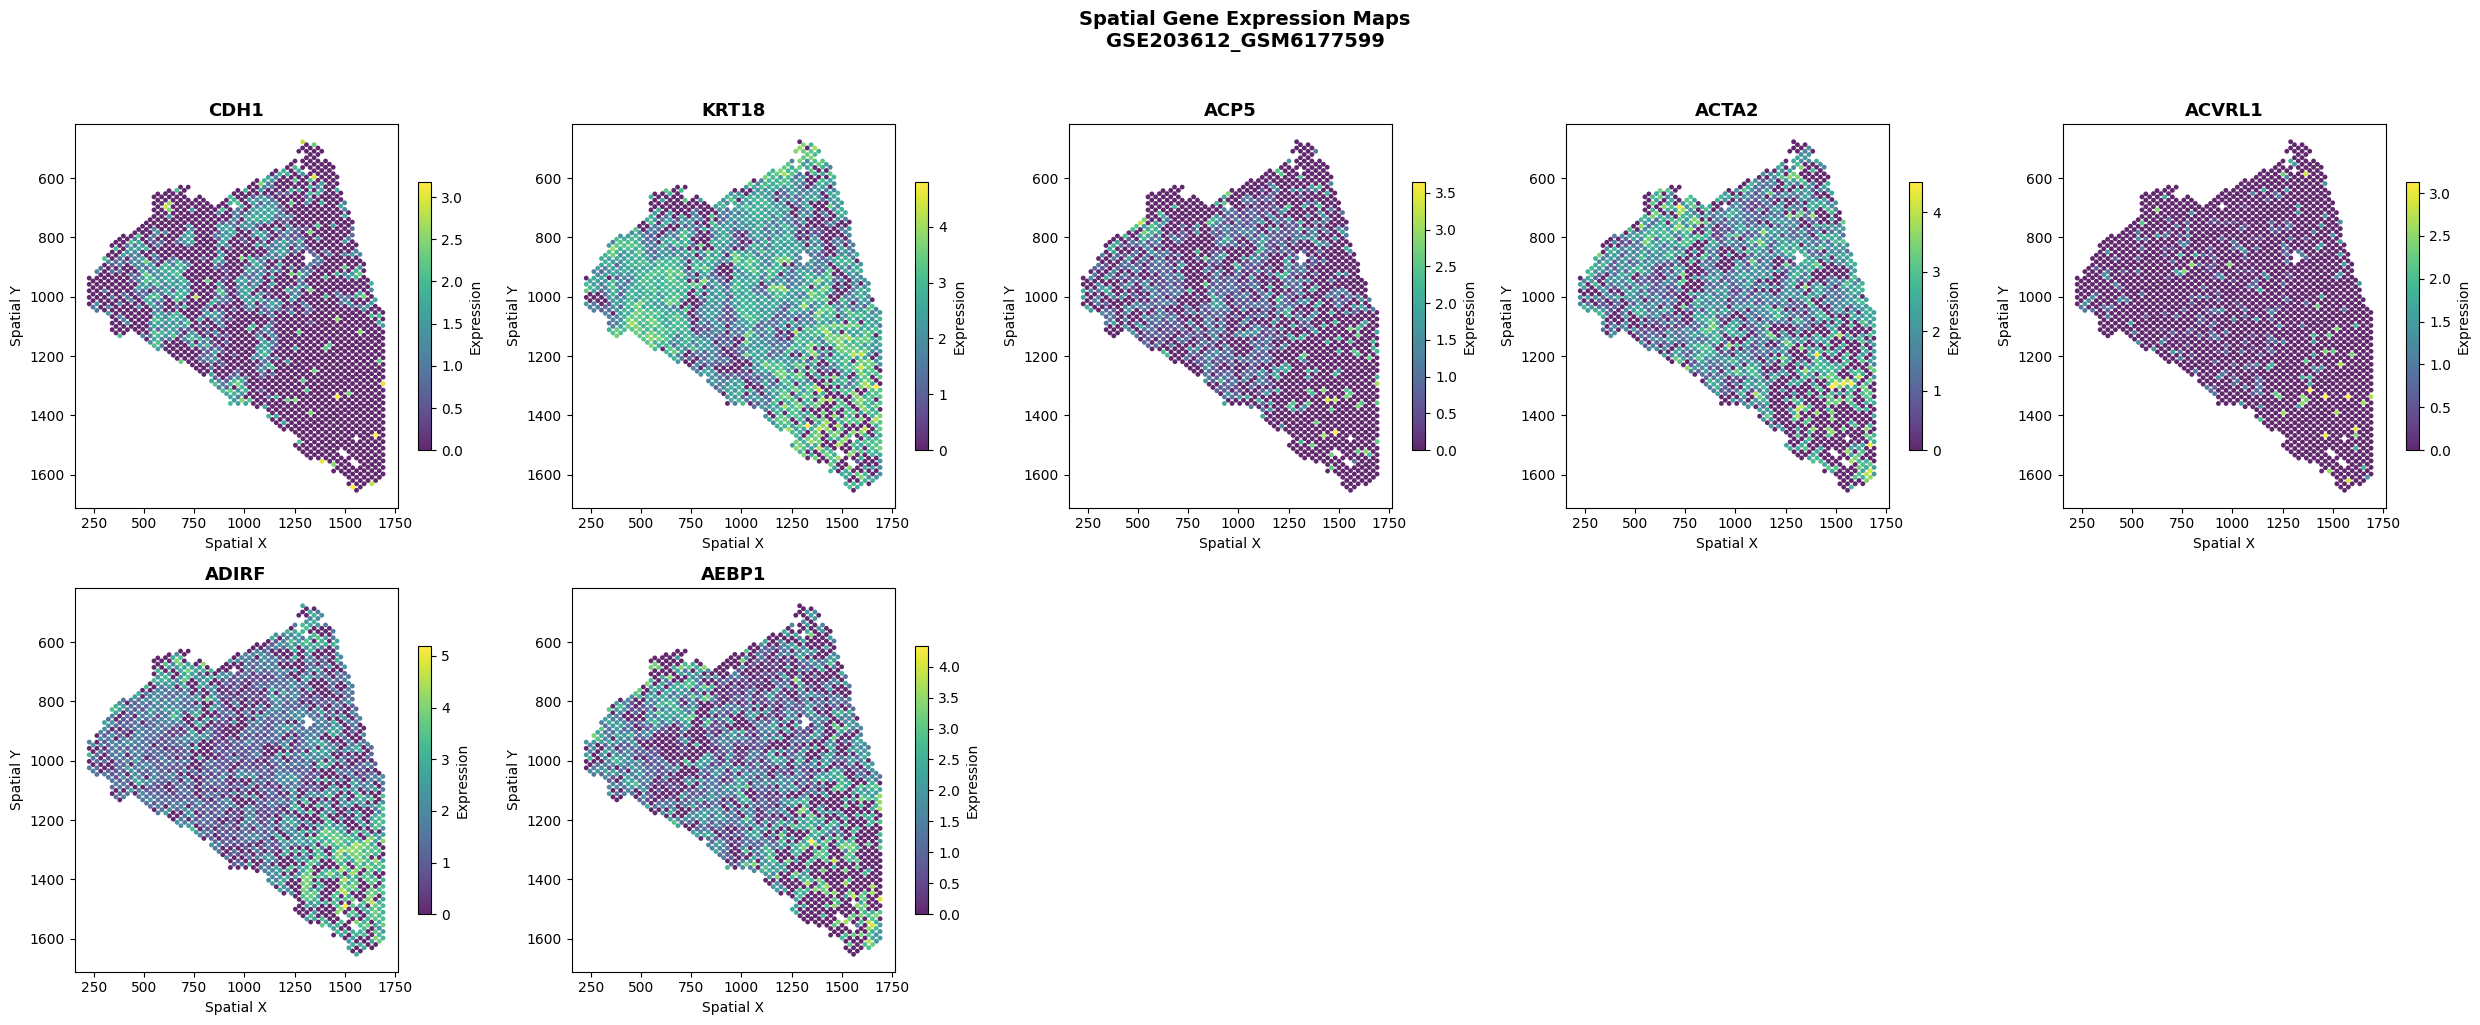

✅ Saved: /content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/spatial_maps/spatial_expression_GSE203612_GSM6177599.png


In [ ]:
## Spatial Gene expression maps

from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed"

# Choose representative samples (change these names)
sample_names = [
    "GSE203612_GSM6177599",   # ← Replace with real names from your train folder
    # Add 1-2 more from train/val if you want
]

# Choose biologically relevant genes (adjust based on what exists in your data)
genes_to_plot = ["CDH1", "KRT18", "ESR1", "MKI67", "TP53", "ACP5", "ACTA2", "ACVRL1", "ADIRF", "AEBP1"]

for sample_name in sample_names:
    adata_path = PROCESSED_DIR / "train" / f"{sample_name}.h5ad"
    if not adata_path.exists():
        print(f"File not found: {sample_name}")
        continue

    adata = sc.read_h5ad(adata_path)
    coords = adata.obsm['spatial']

    # Filter to genes that actually exist
    existing_genes = [g for g in genes_to_plot if g in adata.var_names]

    if len(existing_genes) == 0:
        print(f"No requested genes found in {sample_name}")
        continue

    # Fixed grid for mosaic layout (2 rows, 5 columns)
    n_rows = 2
    n_cols = 5
    max_genes_to_display = n_rows * n_cols

    # Only consider up to max_genes_to_display for plotting
    genes_for_plotting = existing_genes[:max_genes_to_display]
    num_genes_actually_plotted = len(genes_for_plotting)


    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, gene in enumerate(genes_for_plotting): # Iterate over the limited list
        expr = adata[:, gene].X.toarray().flatten() if hasattr(adata.X, "toarray") else adata[:, gene].X.flatten()

        scatter = axes[i].scatter(
            coords[:, 0], coords[:, 1],
            c=expr,
            cmap='viridis',
            s=12,
            alpha=0.85,
            edgecolors='none'
        )
        axes[i].set_title(f"{gene}", fontsize=13, fontweight='bold')
        axes[i].set_xlabel("Spatial X")
        axes[i].set_ylabel("Spatial Y")
        axes[i].invert_yaxis()   # Often better for tissue orientation
        plt.colorbar(scatter, ax=axes[i], shrink=0.7, label="Expression")

    # Hide any unused subplots
    for j in range(num_genes_actually_plotted, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Spatial Gene Expression Maps\n{sample_name}",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Save
    save_dir = PROJECT_ROOT / "visualizations" / "spatial_maps"
    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / f"spatial_expression_{sample_name}.png"
    plt.savefig(save_path, dpi=1200, bbox_inches='tight')
    plt.show() # Display the plot after saving
    # plt.close() # Close the figure after saving to free memory

    print(f"✅ Saved: {save_path}")

### Generate and Save Spatial Gene Expression Maps for All Samples

In [ ]:
from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ====================== PATHS ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
PROCESSED_ST_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed"
VISUALIZATION_MAPS_BASE_DIR = PROJECT_ROOT / "visualizations" / "spatial_maps"

# Define the splits to process
splits = {
    "train": PROCESSED_ST_DIR / "train",
    "val": PROCESSED_ST_DIR / "val",
    "test": PROCESSED_ST_DIR / "test"
}

# Choose biologically relevant genes (adjust based on what exists in your data)
genes_to_plot = ["CDH1", "KRT18", "ESR1", "MKI67", "TP53", "ACP5", "ACTA2", "ACVRL1", "ADIRF", "AEBP1"]

# Fixed grid for mosaic layout (2 rows, 5 columns)
n_rows = 2
n_cols = 5
max_genes_to_display = n_rows * n_cols

print("Starting generation and saving of spatial gene expression maps...")

for split_name, split_dir in splits.items():
    print(f"\nProcessing {split_name.upper()} split from: {split_dir}")

    if not split_dir.exists():
        print(f"  Warning: Directory not found for {split_name}. Skipping.")
        continue

    h5ad_files = sorted(list(split_dir.glob("*.h5ad")))

    if not h5ad_files:
        print(f"  No .h5ad files found in {split_dir}. Skipping {split_name}.")
        continue

    # Create output directory for this split's visualizations
    save_split_dir = VISUALIZATION_MAPS_BASE_DIR / split_name
    save_split_dir.mkdir(parents=True, exist_ok=True)

    for adata_path in tqdm(h5ad_files, desc=f"  Saving maps for {split_name}"):
        sample_name = adata_path.stem

        # Skip if already saved
        output_filename = save_split_dir / f"spatial_expression_{sample_name}.png"
        if output_filename.exists():
            # print(f"  Skipping '{sample_name}': Map already exists at {output_filename}")
            continue

        try:
            adata = sc.read_h5ad(adata_path)
            coords = adata.obsm['spatial']

            # Filter to genes that actually exist in this sample
            existing_genes = [g for g in genes_to_plot if g in adata.var_names]

            if len(existing_genes) == 0:
                print(f"  Warning: No requested genes found in {sample_name}. Skipping map generation.")
                continue

            genes_for_plotting = existing_genes[:max_genes_to_display]
            num_genes_actually_plotted = len(genes_for_plotting)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
            axes = axes.flatten()

            for i, gene in enumerate(genes_for_plotting):
                expr = adata[:, gene].X.toarray().flatten() if hasattr(adata.X, "toarray") else adata[:, gene].X.flatten()

                scatter = axes[i].scatter(
                    coords[:, 0], coords[:, 1],
                    c=expr,
                    cmap='viridis',
                    s=12,
                    alpha=0.85,
                    edgecolors='none'
                )
                axes[i].set_title(f"{gene}", fontsize=13, fontweight='bold')
                axes[i].set_xlabel("Spatial X")
                axes[i].set_ylabel("Spatial Y")
                axes[i].invert_yaxis()
                plt.colorbar(scatter, ax=axes[i], shrink=0.7, label="Expression")

            for j in range(num_genes_actually_plotted, len(axes)):
                axes[j].axis('off')

            plt.suptitle(f"Spatial Gene Expression Maps\n{sample_name}",
                         fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()

            plt.savefig(str(output_filename), dpi=1200, bbox_inches='tight')
            plt.close(fig) # Close the figure to free memory and prevent display

            # print(f"  ✅ Saved: {output_filename}") # Optional: print for each file

        except Exception as e:
            print(f"  ERROR generating map for '{sample_name}': {e}. Skipping this sample.")
            if 'fig' in locals() and plt.fignum_exists(fig.number):
                plt.close(fig)

print("\n\u2705 All spatial gene expression maps generated and saved!")
print(f"Output directory: {VISUALIZATION_MAPS_BASE_DIR}")

Starting generation and saving of spatial gene expression maps...

Processing TRAIN split from: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/train


  Saving maps for train: 100%|██████████| 150/150 [1:07:41<00:00, 27.07s/it]



Processing VAL split from: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/val


  Saving maps for val: 100%|██████████| 27/27 [11:47<00:00, 26.22s/it]



Processing TEST split from: /content/drive/My Drive/MSC Project/SpaHisto-Net/data/processed/st_preprocessed/test


  Saving maps for test: 100%|██████████| 15/15 [07:49<00:00, 31.27s/it]


✅ All spatial gene expression maps generated and saved!
Output directory: /content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/spatial_maps


### SPATIAL KNN OVERLAY

In [5]:
# SPATIAL KNN OVERLAY

from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import triu
import networkx as nx
from tqdm import tqdm

# ====================== CONFIGURATION ======================
PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train"

# Choose a good representative sample (pick one with reasonable number of spots)
sample_name = "GSE203612_GSM6177599"   # ← CHANGE THIS to a real file in your train folder

# Optional: Color spots by a gene (set to None if you just want the graph)
gene_to_color = "CDH1"   # Change to any gene present in your data, or set to None

# Graph visualization settings
max_edges_to_plot = 3000   # Limit edges for clarity (prevents messy plots)
node_size = 8
edge_alpha = 0.3
# ============================================================

adata_path = PROCESSED_DIR / f"{sample_name}.h5ad"

if not adata_path.exists():
    print(f"❌ File not found: {adata_path}")
    print("Please check the sample_name and folder path.")
else:
    print(f"Loading: {sample_name}")
    adata = sc.read_h5ad(adata_path)

    coords = adata.obsm['spatial']
    n_spots = adata.n_obs

    print(f"Number of spots: {n_spots}")
    print(f"Number of genes: {adata.n_vars}")

    # Get spatial connectivities (KNN graph)
    if 'spatial_connectivities' not in adata.obsp:
        print("⚠️ No spatial_connectivities found. Building KNN graph now...")
        from sklearn.neighbors import kneighbors_graph
        spatial_graph = kneighbors_graph(coords, n_neighbors=6, mode='connectivity', include_self=False)
        adata.obsp['spatial_connectivities'] = spatial_graph

    connectivities = adata.obsp['spatial_connectivities']

    # Convert to edge list (use only upper triangle to avoid duplicates)
    connectivities_upper = triu(connectivities, k=1)
    edges = np.array(connectivities_upper.nonzero()).T

    # Subsample edges if too many (for cleaner visualization)
    if len(edges) > max_edges_to_plot:
        np.random.seed(42)
        edges = edges[np.random.choice(len(edges), max_edges_to_plot, replace=False)]

    print(f"Plotting {len(edges)} edges out of {connectivities.nnz} total connections")

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10))

    # Color spots
    if gene_to_color and gene_to_color in adata.var_names:
        expr = adata[:, gene_to_color].X.toarray().flatten() if hasattr(adata.X, "toarray") else adata[:, gene_to_color].X.flatten()
        scatter = ax.scatter(coords[:, 0], coords[:, 1],
                             c=expr, cmap='viridis', s=node_size, alpha=0.9, zorder=2)
        plt.colorbar(scatter, ax=ax, shrink=0.6, label=f"{gene_to_color} Expression")
        title_color = f"colored by {gene_to_color}"
    else:
        ax.scatter(coords[:, 0], coords[:, 1],
                   c='#2E86AB', s=node_size, alpha=0.7, zorder=2)
        title_color = "colored by spatial position"

    # Draw KNN edges
    for start, end in edges:
        ax.plot([coords[start, 0], coords[end, 0]],
                [coords[start, 1], coords[end, 1]],
                color='#E63946', alpha=edge_alpha, linewidth=0.6, zorder=1)

    ax.set_title(f"Spatial KNN Graph Overlay\n{sample_name}\n{title_color}",
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Spatial Coordinate X", fontsize=11)
    ax.set_ylabel("Spatial Coordinate Y", fontsize=11)
    ax.invert_yaxis()  # Usually better for tissue images
    ax.set_aspect('equal')
    ax.grid(False)

    # Add text box with info
    textstr = f"Spots: {n_spots}\nGenes: {adata.n_vars}\nKNN neighbors: 6"
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()

    # Save figure
    save_dir = PROJECT_ROOT / "visualizations" / "spatial_knn"
    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / f"spatial_knn_overlay_{sample_name}.png"

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print(f"\n✅ Saved high-quality figure to:\n{save_path}")

Loading: GSE203612_GSM6177599
Number of spots: 2377
Number of genes: 1991
Plotting 3000 edges out of 14262 total connections

✅ Saved high-quality figure to:
/content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/spatial_knn/spatial_knn_overlay_GSE203612_GSM6177599.png


### HVG Heatmap with Leiden Clustering + Row Colors

In [ ]:
pip install leidenalg
"Human_Breast_Andersson_10142021_ST_A2", "GSE242311_GSM7757970"

In [11]:
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT_ROOT = Path("/content/drive/My Drive/MSC Project/SpaHisto-Net")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "st_preprocessed" / "train"

sample_name = "GSE203612_GSM6177599"  # ← Change this

n_top_hvgs = 20          # Smaller version
resolution = 0.8

adata = sc.read_h5ad(PROCESSED_DIR / f"{sample_name}.h5ad")

# Filter to HVGs and select top 20
if 'highly_variable' in adata.var.columns:
    adata_hvg = adata[:, adata.var['highly_variable']].copy()
else:
    adata_hvg = adata.copy()

if adata_hvg.n_vars > n_top_hvgs:
    gene_vars = np.var(adata_hvg.X.toarray() if hasattr(adata_hvg.X, "toarray") else adata_hvg.X, axis=0)
    top_idx = np.argsort(gene_vars)[-n_top_hvgs:]
    adata_hvg = adata_hvg[:, top_idx].copy()

# Leiden clustering using spatial graph
if 'spatial_connectivities' in adata_hvg.obsp:
    sc.tl.leiden(adata_hvg, adjacency=adata_hvg.obsp['spatial_connectivities'],
                 resolution=resolution, key_added='leiden_spatial', random_state=42)
    cluster_key = 'leiden_spatial'
else:
    sc.pp.neighbors(adata_hvg, n_neighbors=15, random_state=42)
    sc.tl.leiden(adata_hvg, resolution=resolution, random_state=42)
    cluster_key = 'leiden'

n_clusters = adata_hvg.obs[cluster_key].nunique()

# Prepare data
expr_df = pd.DataFrame(
    adata_hvg.X.toarray() if hasattr(adata_hvg.X, "toarray") else adata_hvg.X,
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)

cluster_labels = adata_hvg.obs[cluster_key].astype(str)
palette = sns.color_palette("tab20", n_colors=n_clusters)
cluster_colors = dict(zip(sorted(cluster_labels.unique()), palette))
row_colors = cluster_labels.map(cluster_colors)

# Create clustermap
g = sns.clustermap(
    expr_df,
    cmap="viridis",
    figsize=(14, 9),
    dendrogram_ratio=0.1,
    cbar_pos=(0.02, 0.82, 0.03, 0.12),
    xticklabels=True,
    yticklabels=False,
    standard_scale=0,
    method='ward',
    metric='euclidean',
    row_colors=row_colors
)

g.ax_heatmap.set_title(f"Top {n_top_hvgs} HVGs with Leiden Clusters\n{sample_name}",
                       fontsize=14, fontweight='bold', pad=20)
g.ax_heatmap.set_xlabel("Highly Variable Genes", fontsize=11)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=7)

# Legend
legend_patches = [Patch(facecolor=cluster_colors[str(c)], label=f"Cluster {c}")
                  for c in sorted(cluster_labels.unique())]
g.ax_heatmap.legend(handles=legend_patches, title="Leiden Clusters",
                    bbox_to_anchor=(1.22, 1.0), loc='upper left', fontsize=9)

plt.tight_layout()

save_path = PROJECT_ROOT / "visualizations" / "hvg_heatmaps" / f"hvg_heatmap_top{n_top_hvgs}_{sample_name}.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
plt.close()

print(f"✅ Saved smaller version: {save_path}")

/tmp/ipykernel_21036/95156666.py:32: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hvg, adjacency=adata_hvg.obsp['spatial_connectivities'],
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


✅ Saved smaller version: /content/drive/My Drive/MSC Project/SpaHisto-Net/visualizations/hvg_heatmaps/hvg_heatmap_top20_GSE203612_GSM6177599.png
